## Visión por Computadora II
### Carrera de Especialización en Inteligencia Artificial - FIUBA

## Trabajo Práctico Final

### 2º Bimestre 2025

### Grupo

| Autores               | E-mail                    | Nº SIU  |
|---------------------- |---------------------------|---------|
| Braian Desía          | b.desia@hotmail.com       | a1804   |
| Lautaro Medina        | medinalautarog@gmail.com  | a1813   |

# **PLANT DISEASE DETECTION**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar cuando una planta está enferma o no.

El dataset se encuentra en este link: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset.

La fuente original del dataset es el siguiente repositorio de github: https://github.com/spMohanty/PlantVillage-Dataset.git.

Allí se presentan 3 versiones de la base de datos en el directorio "raw".

- color : Original RGB images
- grayscale : grayscaled version of the raw images
- segmented : RGB images with just the leaf segmented and color corrected.



### 0. LIBRERÍAS GENERALES

In [4]:
import numpy as np                  # For data manipulation
import pandas as pd                 # For data manipulation
import os                           # For path manipulation
import matplotlib.pyplot as plt     # For visualization
import torch                        # For neural networks models
from tqdm import tqdm               # For progress bar

### 1. EXPLORATORY DATA ANALYSIS

#### 1.1 PRELIMINAR

In [5]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Clonar el repositorio completo de github para el dataset
    !git clone https://github.com/spMohanty/PlantVillage-Dataset.git

    # Importar os para cambiar directorio
    import os

    # Cambiar a la carpeta 'raw'
    os.chdir('PlantVillage-Dataset/raw')

    # Verificar los archivos en la carpeta 'raw'
    print(os.listdir('.'))

    # Fijo la dirección del dataset
    base_dir = os.getcwd()

    # Instalar torchinfor
    !pip install torchinfo

    # Clonar el repositorio completo de github del proyecto (para tener los modelos entrenados)
    !git clone https://github.com/bdesia-nasa/vc1_tp2.git

else:
    base_dir = './plantvillage dataset/'

def dataset_folderpath(dataset_name):
    return os.path.join(base_dir, dataset_name) + '/'

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163235, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 163235 (delta 2), reused 1 (delta 0), pack-reused 163229 (from 1)
Receiving objects: 100% (163235/163235), 2.00 GiB | 17.81 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (182401/182401), done.
['segmented', 'grayscale', 'color']
Cloning into 'vc1_tp2'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 8), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 1.90 MiB | 2.84 MiB/s, done.
Resolving deltas: 100% (8/8), done.


El dataset presenta 3 carpetas:
- color
- grayscale
- segmented

Esas carpetas tienen, a su vez, subcarpetas con las categorías.

Comparamos la cantidad de archivos en las 3 carpetas, por categoría.

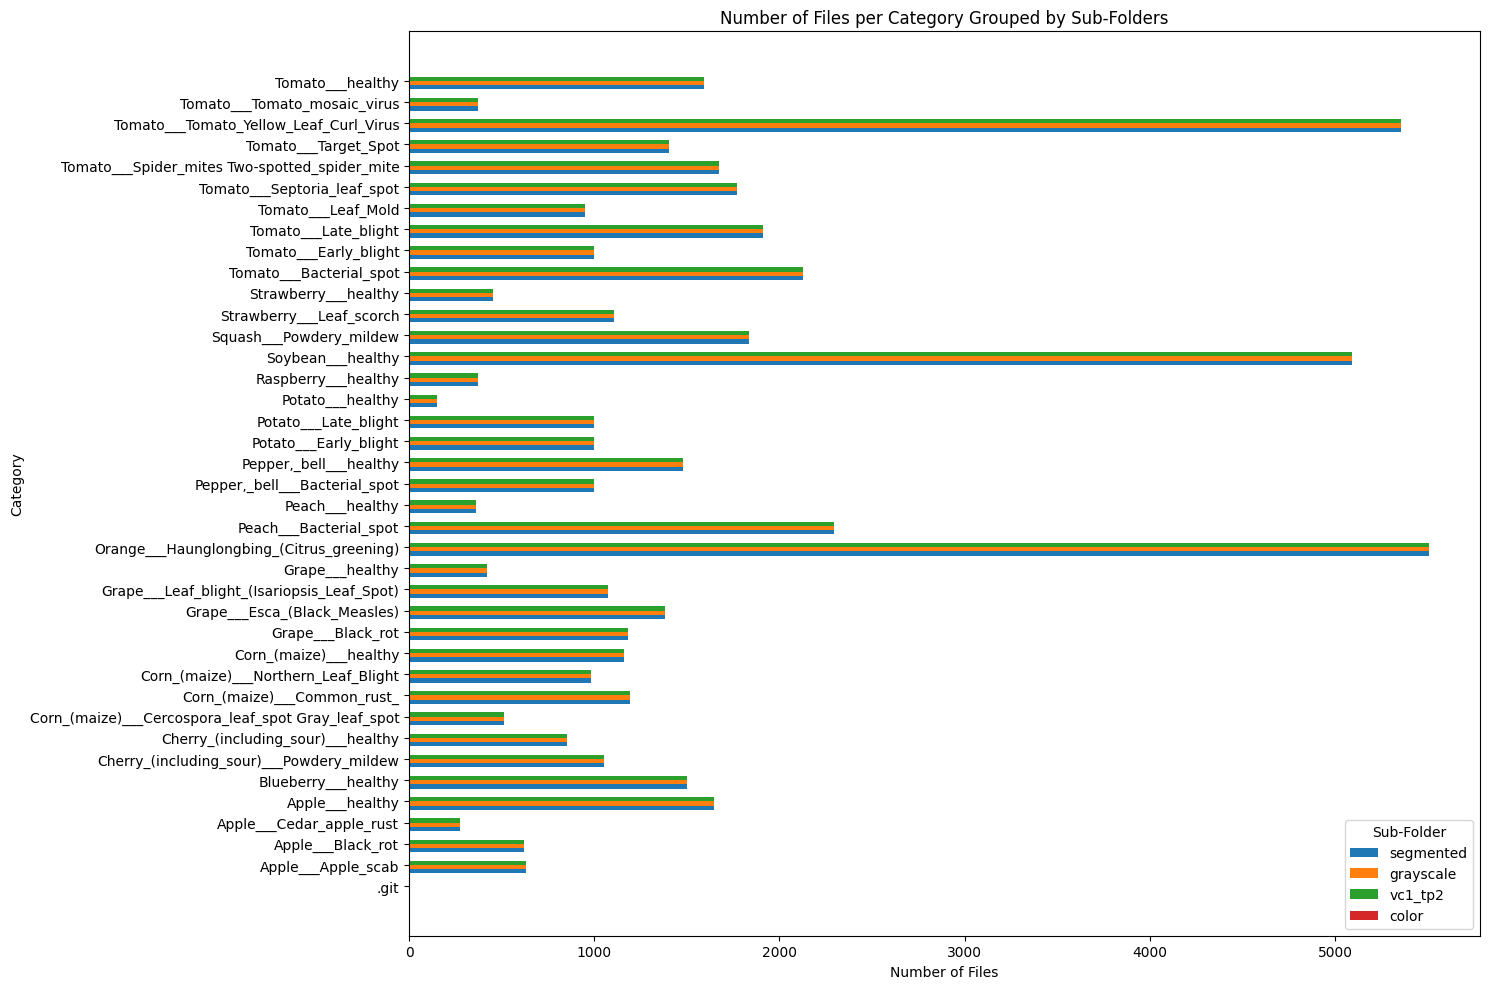

In [6]:
# List sub-folders in the main directory
subfolders = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# Initialize dictionary to store data: {sub_subfolder: [file counts per subfolder]}
data = {}

# Iterate over each subfolder
for subc in subfolders:
    subc_path = os.path.join(base_dir, subc)
    # List sub-sub-folders
    sub_subs = [d for d in os.listdir(subc_path) if os.path.isdir(os.path.join(subc_path, d))]
    for sub_sub in sub_subs:
        sub_sub_path = os.path.join(subc_path, sub_sub)
        # Count files in each sub-sub-folder
        files = [f for f in os.listdir(sub_sub_path) if os.path.isfile(os.path.join(sub_sub_path, f))]
        if sub_sub not in data:
            data[sub_sub] = []
        data[sub_sub].append(len(files))

# Sort the sub-sub-folders
sub_subs_sorted = sorted(data.keys())

# Number of groups and bars
num_groups = len(sub_subs_sorted)
num_bars = len(subfolders)

# Create the figure with more height for horizontal bars
fig, ax = plt.subplots(figsize=(15, 10))

# Bar height
total_width = 0.8
bar_height = total_width / num_bars

# Positions on the y-axis
indices = np.arange(num_groups)

# Create horizontal bars
for i, subc in enumerate(subfolders):
    # Get data sorted according to sub_subs_sorted
    values = [data[sub_sub][i] if i < len(data[sub_sub]) else 0 for sub_sub in sub_subs_sorted]
    # Y-position for this set of bars
    pos = indices - total_width/2 + i * bar_height + bar_height/2
    ax.barh(pos, values, height=bar_height, label=subc)

# Configure labels and legend
ax.set_ylabel('Category')
ax.set_xlabel('Number of Files')
ax.set_title('Number of Files per Category Grouped by Sub-Folders')
ax.set_yticks(indices)
ax.set_yticklabels(sub_subs_sorted)
ax.legend(title='Sub-Folder')

plt.tight_layout()
plt.show()

In [7]:
# List to store the names of classes with discrepancies
discrepant_classes = []

# Check if each sub-sub-folder has the same number of files across all sub-folders
all_match = True

for sub_sub in sub_subs_sorted:
    file_counts = data[sub_sub]
    # Verify if all counts are the same
    if len(set(file_counts)) != 1:
        print(f"Mismatch found in class: {sub_sub}")
        discrepant_classes.append(sub_sub)  # Save class with discrepancy
        all_match = False

if all_match:
    print("For each class, all sub-folders have the same number of files.")

Mismatch found in class: Grape___Esca_(Black_Measles)


In [8]:
# Veamos para la clase con la diferencia encontrada
if len(discrepant_classes) > 0:
  data [discrepant_classes[0]]

Vemos cual es el archivo que esta de más:

In [9]:

# List files in each folder
files_folder1 = set(os.listdir(dataset_folderpath('color/' + discrepant_classes[0])))
files_folder2 = set(os.listdir(dataset_folderpath('segmented/' + discrepant_classes[0])))

# Create a set for filenames without extension or suffix
mask_suffix = '_final_masked'

files_folder2_without_mask = set()

for filename in files_folder2:
    # Remove the extension
    base_name, ext = os.path.splitext(filename)
    # Remove the suffix
    base_name = base_name[:-len(mask_suffix)]
    files_folder2_without_mask.add(base_name)

files_folder1_names = set()
for filename in files_folder1:
    name, ext = os.path.splitext(filename)
    files_folder1_names.add(name)

# Count matches
matches = files_folder1_names.intersection(files_folder2_without_mask)
non_matches = files_folder1_names.symmetric_difference(files_folder2_without_mask)

print(f"Number of files with the same name: {len(matches)}")
print(f"Number of files without a match: {len(non_matches)}")
print('')

non_matching_files = [filename for filename in non_matches]
print("Files in folder2 with no corresponding match in folder1:")
for filename in non_matches:
    print(filename)

Number of files with the same name: 1383
Number of files without a match: 1

Files in folder2 with no corresponding match in folder1:
7e1fd9b9-1fd9-4f98-93f5-8cf9ebc60dd9___FAM_B.Msls 4430


**OBSERVACIONES:**

- Con excepción de la clase "Grape__Esca_(Black_Measles)", se infiere que cada sub-carpeta, presenta los mismos casos por clase pero diferenciandose en que las imagenes están a color, en escala de grises y segmentadas, respectivamente.

- Para la clase "Grape__Esca_(Black_Measles)", la sub-carpeta "segmented" presenta 1 archivo más respecto de las otras 2 carpetas.

#### 1.1 DATA ANALYSIS

Cargamos los datasets:

In [10]:
from torchvision import datasets

# Cargar los diferentes datasets
dataset_color = datasets.ImageFolder(root = dataset_folderpath('color'))
dataset_gray = datasets.ImageFolder(root = dataset_folderpath('grayscale'))
dataset_seg = datasets.ImageFolder(root = dataset_folderpath('segmented'))

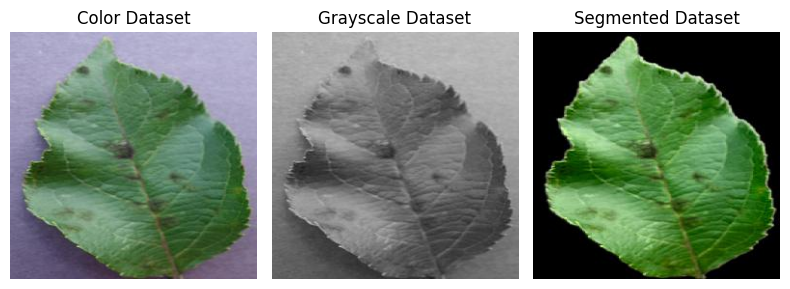

In [11]:
# Function to display a list of images in a row
def show_images_in_row(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(8, 5))
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Sample one image from each dataset
images = []
titles = ['Color Dataset', 'Grayscale Dataset', 'Segmented Dataset']
samples = [
    dataset_color,
    dataset_gray,
    dataset_seg
]

for dataset in samples:
    image, label = dataset[0]
    images.append(image)

# Show all three images in a row
show_images_in_row(images, titles)



**OBSERVACIONES:**

- Se asume a la carpeta "color" como la original sin procesamiento, siendo "grayscale" y "segmented" versiones procesadas de esta carpeta.

- Dado que nuestro interes está en analizar la hoja en si y su fondo no aporta valor alguno, utilizar el conjunto con la imagen segmentada resulta atractivo, aunque, por otra parte, para nuevas inferencias, se debería proveer la imagen segmentada.

Veamos el tamaño de las imágenes del dataset:

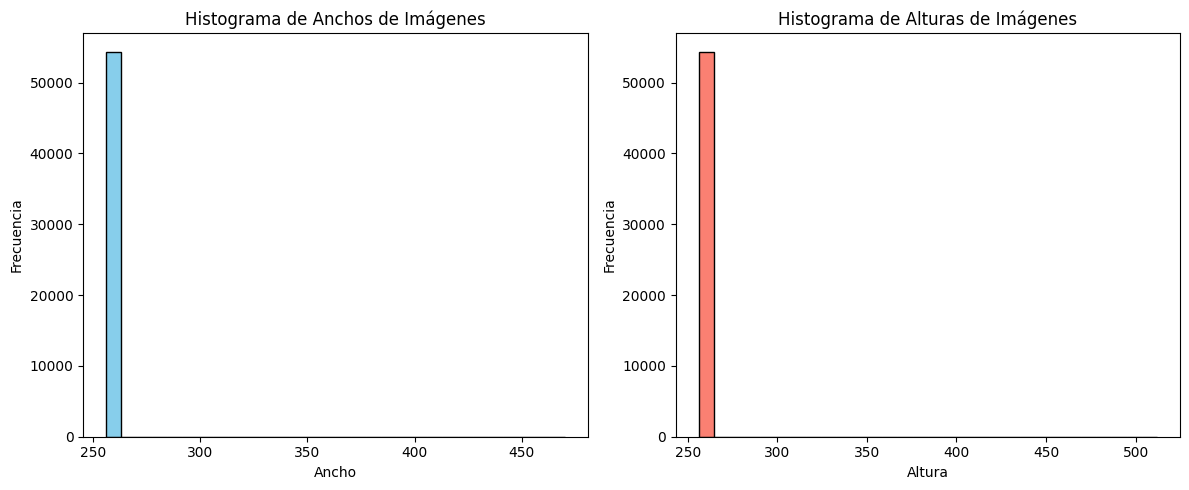

Ancho mínimo: 256, Ancho máximo: 470
Altura mínima: 256, Altura máxima: 512


In [12]:
# Variables para almacenar dimensiones
widths = []
heights = []

# Inicializar las alturas y anchuras
min_height = float('inf')
max_height = float('-inf')
min_width = float('inf')
max_width = float('-inf')

# Iterar sobre el conjunto de datos para recolectar dimensiones
for img, label in dataset:
    width, height = img.size
    widths.append(width)
    heights.append(height)

min_width = min(widths)
max_width = max(widths)
min_height = min(heights)
max_height = max(heights)

# Graficar histograma de anchos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma de Anchos de Imágenes')
plt.xlabel('Ancho')
plt.ylabel('Frecuencia')

# Graficar histograma de alturas
plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='salmon', edgecolor='black')
plt.title('Histograma de Alturas de Imágenes')
plt.xlabel('Altura')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Ancho mínimo: {min_width}, Ancho máximo: {max_width}")
print(f"Altura mínima: {min_height}, Altura máxima: {max_height}")

<ipython-input-13-3128316254>:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([widths, heights], labels=['Widths', 'Heights'])


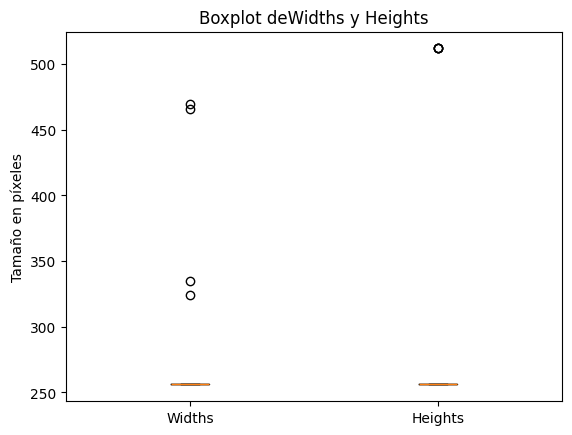

In [13]:
plt.boxplot([widths, heights], labels=['Widths', 'Heights'])
plt.ylabel('Tamaño en píxeles')
plt.title('Boxplot deWidths y Heights')
plt.show()

In [14]:
avg_width = sum(widths) / len(widths)
avg_height = sum(heights) / len(heights)

print(f"Ancho promedio: {avg_width}")
print(f"Altura promedio: {avg_height}")

Ancho promedio: 256.010514491953
Altura promedio: 256.0188561116635


**OBSERVACIONES:**

- Vemos que prácticamente todas las imagenes tiene 256x256 de tamaño, con excepción de unos pocos outliers.

- La relación de aspecto es 1 el prácticamente la mayoría de las imágenes.

- Para el procesamiento, aplicaremos un transform para igualar el tamaño de todas las imágenes o podríamos directamente eliminar los outliers sin mayor perjucio.

In [15]:
nclasses = len(dataset_color.classes)
class_names = dataset_color.classes

print("La cantidad de clases es: ", nclasses)
print("Las clases son: ", class_names)
print("Índice a Clase: ", dataset_color.class_to_idx)

La cantidad de clases es:  38
Las clases son:  ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mite

**OBSERVACIONES:**

- Las clases tienen la siguiente nomenclatura {PLANTA} + ___ + {CONDICIÓN}

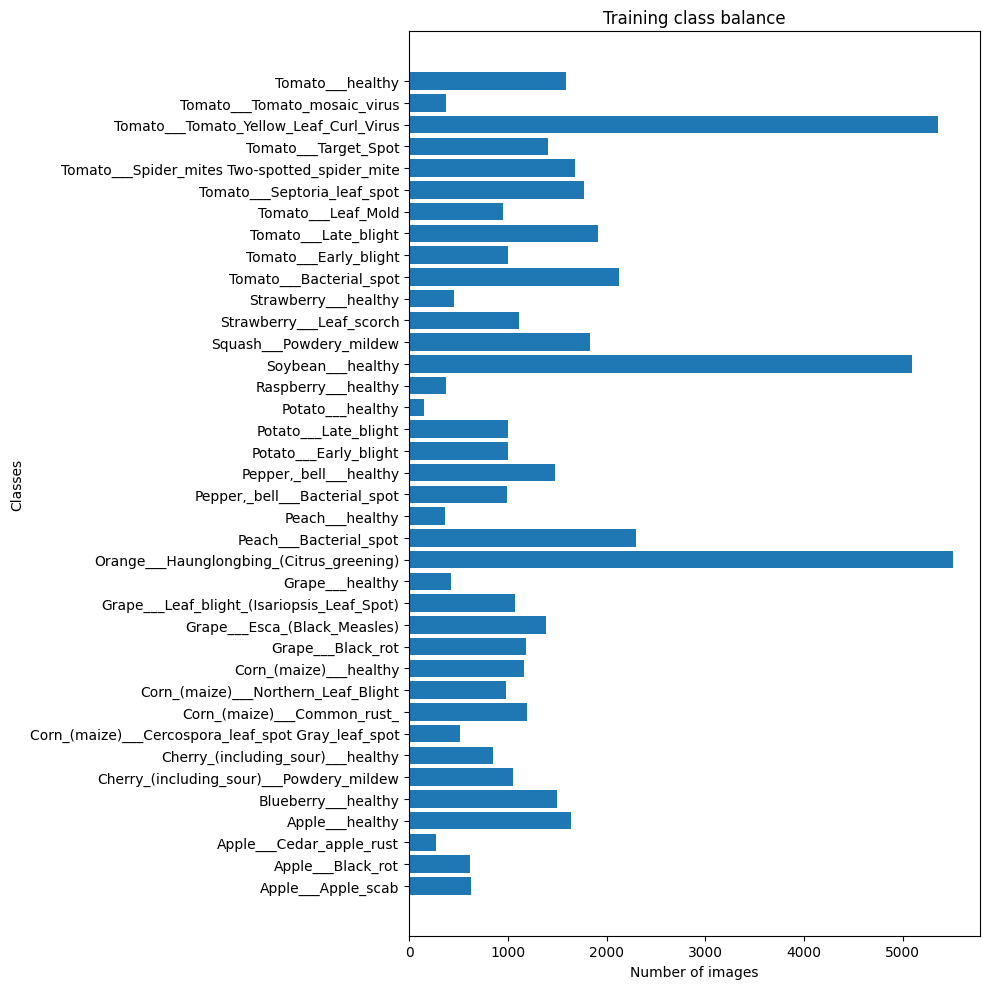

In [16]:
from collections import Counter

# Count the classes in the training set
class_names = dataset_color.classes
class_counts = Counter(sample[1] for sample in dataset_color.samples)

# Get class names and their counts
classes = [class_names[i] for i in range(len(class_names))]
counts = [class_counts[i] for i in range(len(class_names))]

# Create the horizontal bar chart
plt.figure(figsize=(10, 10))
plt.barh(classes, counts)
plt.title('Training class balance')
plt.xlabel('Number of images')
plt.ylabel('Classes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- Vemos que hay un desbalance notorio de clases.

Sampleamos algunas imagenes por clase

In [17]:
import random
from torchvision.transforms import v2           # usamos v2 porque es más rápido y presenta más capacidades

# Create a dictionary to store the image tensors by folder
img_data = {}
for img_path, label in dataset_color.samples:
    folder_name = dataset_color.classes[label]  # Gets the folder name from the dataset
    if folder_name not in img_data:
        img_data[folder_name] = []
    img_data[folder_name].append(img_path)

# Define the transformation
ToTensor_transform = v2.Compose([                   # Replace v1.ToTensor(): Convert images to tensor between [0,1]
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

# Sample and display images
for i, folder in enumerate(img_data.keys()):
    print(folder)
    sample_size = 10
    # Ensure there are enough images in the folder
    if len(img_data[folder]) < sample_size:
        print(f"Not enough images in folder '{folder}' for sampling.")
        continue

    # Randomly sample image paths and apply transformations
    sampled_images = random.sample(img_data[folder], sample_size)

    # Note: This part still uses Image for loading but can be replaced depending on the available format
    tensors = [ToTensor_transform(datasets.folder.default_loader(path)) for path in sampled_images]

    # Create a grid of images
    plt.figure(figsize=(15, 5))
    for index, img_tensor in enumerate(tensors):
        plt.subplot(1, sample_size, index + 1)  # Create a subplot for each image
        plt.imshow(img_tensor.permute(1, 2, 0))  # Change tensor shape from (C, H, W) to (H, W, C)
        plt.axis('off')  # Hide axes

    plt.show()  # Display the images

Output hidden; open in https://colab.research.google.com to view.

**OBSERVACIONES:**

- En general, las que tienen una condición "Healthy", vemos que predomina enteramente el color verde, mientras que en los casos con enfermedad, se observan manchas o diferentes tonalidades (p.ej., amarillo). Con este criterio, vemos que considerar la imagen a color puede ser relevante para disernir el estado.

- Otro parámetro que se observa es que en las plantas enfermas, se observan "huecos". Alguna técnica de segmentación de bordes (p.ej., Canny) podría usarse para facilitar la clasificación.

Agrupemos en 2 casos macro: Healthy / Disease:

In [18]:
# Find the indices of classes that match '___healthy' and those that don't
healthy_indices = [i for i, cls in enumerate(class_names) if '___healthy' in cls]
diseased_indices = [i for i, cls in enumerate(class_names) if '___healthy' not in cls]

# Count total images per class
class_counts = Counter(sample[1] for sample in dataset_color.samples)

# Sum counts for 'healthy' classes
healthy_total = sum(class_counts.get(idx, 0) for idx in healthy_indices)
# Sum counts for 'other' classes
diseased_total = sum(class_counts.get(idx, 0) for idx in diseased_indices)

print(f"Images labeled as 'healthy': {healthy_total}")
print(f"Images labeled as 'diseased': {diseased_total}")
print(f"Ratio 'healthy/diseased': {(healthy_total/diseased_total):.2f}")

Images labeled as 'healthy': 15084
Images labeled as 'diseased': 39221
Ratio 'healthy/diseased': 0.38


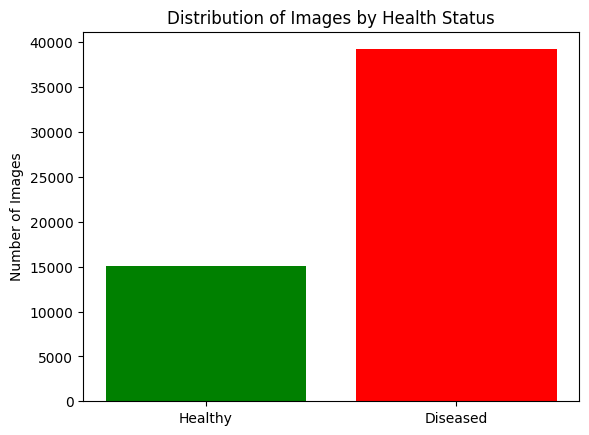

In [19]:
# Data for the bar chart
labels = ['Healthy', 'Diseased']
counts = [healthy_total, diseased_total]

# Create a bar plot with specified colors
plt.bar(labels, counts, color=['green', 'red'])

# Add labels and title
plt.ylabel('Number of Images')
plt.title('Distribution of Images by Health Status')

# Display the plot
plt.show()

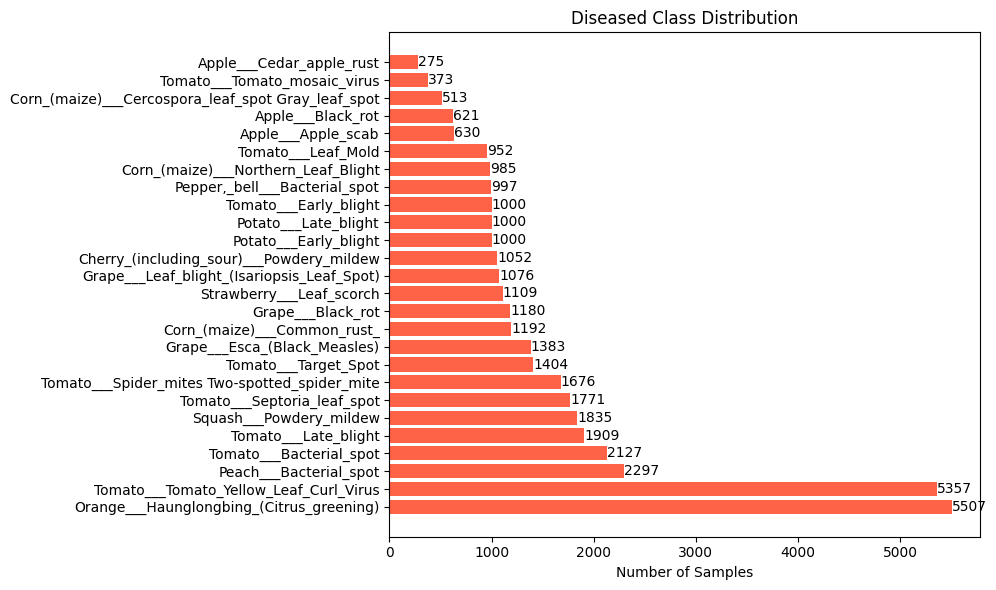

In [20]:
class_counts = Counter(sample[1] for sample in dataset_color.samples)

# Filter only diseased classes
diseased_class_counts = {
    class_names[cls]: count
    for cls, count in class_counts.items()
    if '___healthy' not in class_names[cls]
}

# Sort by count (optional)
diseased_class_counts = dict(sorted(diseased_class_counts.items(), key=lambda item: item[1], reverse=True))

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(list(diseased_class_counts.keys()), list(diseased_class_counts.values()), color='tomato')
plt.xlabel('Number of Samples')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, str(width), va='center')
plt.title('Diseased Class Distribution')
plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- Como podemos ver hay algunos casos de enfermedades en los que se cuenta con pocos datos, es posible que para esto se tenga que generar algunas muestras, o la precision del modelo sea peor.

Veamos ahora la clasificación binaria, pero por especie de planta.

In [21]:
# Obtenemos las especies del dataset:
plant_species = list(set(cls.split('___')[0] for cls in class_names))
plant_species

['Potato',
 'Peach',
 'Pepper,_bell',
 'Blueberry',
 'Soybean',
 'Raspberry',
 'Squash',
 'Orange',
 'Cherry_(including_sour)',
 'Apple',
 'Tomato',
 'Strawberry',
 'Corn_(maize)',
 'Grape']

In [22]:
n_species = len(plant_species)
print("Amount of plant species in the dataset: ", n_species)

Amount of plant species in the dataset:  14


In [23]:

# Count the number of samples per class index in your dataset
class_counts = Counter(sample[1] for sample in dataset_color.samples)

# List the class indices that correspond to 'healthy' classes
healthy_indices = [i for i, cls in enumerate(class_names) if '___healthy' in cls]

# List the class indices that do NOT correspond to 'healthy' classes (i.e., diseased)
diseased_indices = [i for i, cls in enumerate(class_names) if '___healthy' not in cls]

# Initialize a list to store data for each plant species
data = []

# Calculate the total number of samples in the dataset
total_samples = sum(class_counts.values())

# Loop over each plant species
for sp in plant_species:
    # Find all class indices corresponding to this species
    class_idx_for_sp = [i for i, name in enumerate(class_names) if name.startswith(sp + '___')]

    # Sum of healthy class counts for this species
    healthy_total = sum(class_counts.get(idx, 0) for idx in class_idx_for_sp if idx in healthy_indices)

    # Sum of diseased class counts for this species
    diseased_total = sum(class_counts.get(idx, 0) for idx in class_idx_for_sp if idx in diseased_indices)

    # Total samples for this species
    total_especie = healthy_total + diseased_total

    # Fraction of total dataset
    frac = total_especie / total_samples if total_samples > 0 else 0

    # Fraction of healthy and diseased within that species
    healthy_fraction_species = healthy_total / total_especie if total_especie > 0 else 0
    diseased_fraction_species = diseased_total / total_especie if total_especie > 0 else 0

    # Append data with all info
    data.append({
        'plant_species': sp,
        'n_instances': total_especie,
        'fraction': frac,
        'healthy_count': healthy_total,
        'diseased_count': diseased_total,
        'healthy_fraction_in_species': healthy_fraction_species,
        'diseased_fraction_in_species': diseased_fraction_species
    })

# Convert to DataFrame
df = pd.DataFrame(data)
df = pd.DataFrame(data).set_index('plant_species')

# Mostrar la tabla
print(df)

                         n_instances  fraction  healthy_count  diseased_count  \
plant_species                                                                   
Potato                          2152  0.039628            152            2000   
Peach                           2657  0.048927            360            2297   
Pepper,_bell                    2475  0.045576           1478             997   
Blueberry                       1502  0.027659           1502               0   
Soybean                         5090  0.093730           5090               0   
Raspberry                        371  0.006832            371               0   
Squash                          1835  0.033791              0            1835   
Orange                          5507  0.101409              0            5507   
Cherry_(including_sour)         1906  0.035098            854            1052   
Apple                           3171  0.058392           1645            1526   
Tomato                      

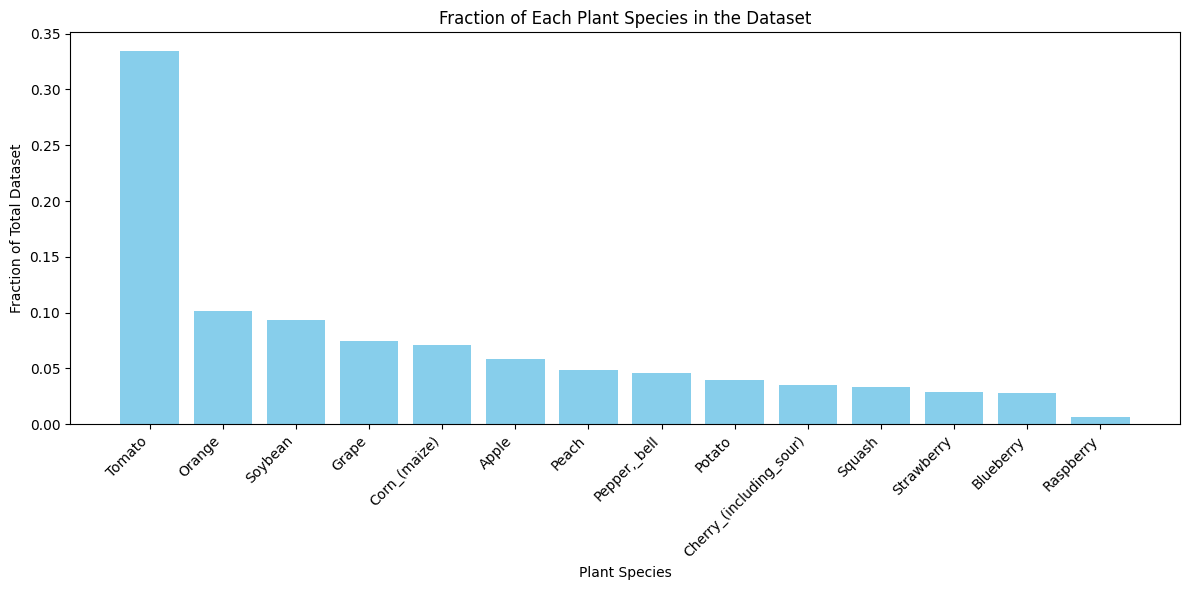

In [24]:
import matplotlib.pyplot as plt

# Ordenar el DataFrame por 'fraction' si quieres
df_sorted = df.sort_values(by='fraction', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_sorted.index, df_sorted['fraction'], color='skyblue')

# Añadir etiquetas y título
plt.xlabel('Plant Species')
plt.ylabel('Fraction of Total Dataset')
plt.title('Fraction of Each Plant Species in the Dataset')
plt.xticks(rotation=45, ha='right')  # rotar etiquetas para mejor visibilidad

# Mostrar la gráfica
plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- Se observa una preponderancia marcada de la especie Tomate en el dataset, superando en 3 veces al inmediato siguiente.

- Si usasemos un modelo baseline que clasificase la especie de la planta usando la especie más frecuente, tendríamos un accuracy de 0.334. Cualquier modelo que implementemos deberá superar ese valor de accuracy para determinar la especie.

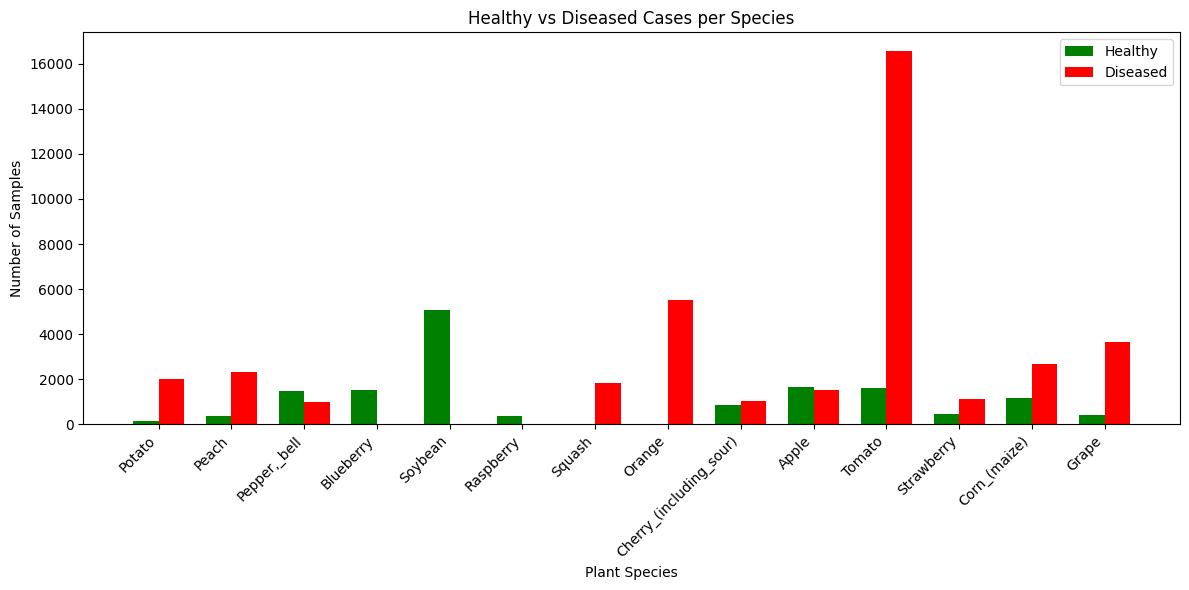

In [25]:
# Extract data from the DataFrame
species = df.index
healthy_counts = df['healthy_count']
diseased_counts = df['diseased_count']

# Positions for the grouped bars
x = np.arange(n_species)
width = 0.35  # Width of each bar

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot 'Healthy' counts
ax.bar(x - width/2, healthy_counts, width, label='Healthy', color='green')

# Plot 'Diseased' counts
ax.bar(x + width/2, diseased_counts, width, label='Diseased', color='red')

# Add labels and title
ax.set_xlabel('Plant Species')
ax.set_ylabel('Number of Samples')
ax.set_title('Healthy vs Diseased Cases per Species')

# Set x-ticks to correspond to species names
ax.set_xticks(x)
ax.set_xticklabels(species, rotation=45, ha='right')

# Add a legend
ax.legend()

# Adjust layout to prevent overlap and display the plot
plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- En la mayoría de las especies se observa el desbalance de clase, con excepción de las manzanas, cereza y ají donde las clases estan relativamente balanceadas.

- Se deduce que gran parte del desbalanceo del set es atribuida a la especie tomate.

In [26]:
print('Healthy cases without Tomato: ', counts[0] - df.loc['Tomato', 'healthy_count'])
print('Diseased cases without Tomato: ', counts[1] - df.loc['Tomato', 'diseased_count'])

Healthy cases without Tomato:  13493
Diseased cases without Tomato:  22652


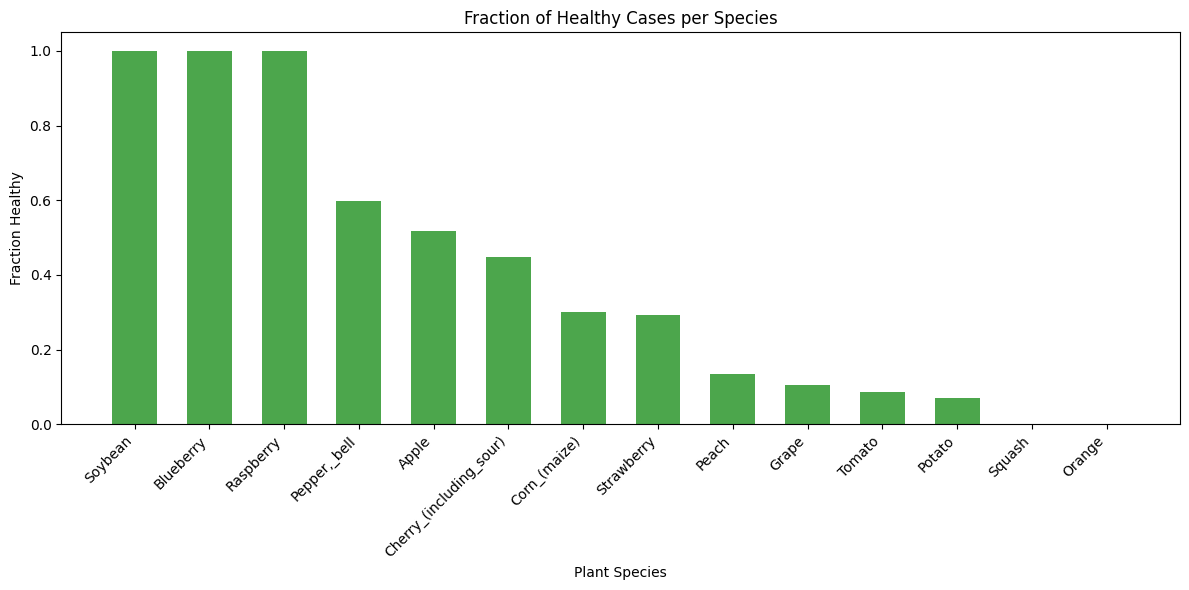

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Extract columns
species = df.index
healthy_fractions = df['healthy_fraction_in_species']

# Create a DataFrame for sorting
df_sorted = pd.DataFrame({
    'species': species,
    'healthy_fraction': healthy_fractions
})

# Sort by healthy_fraction in descending order
df_sorted = df_sorted.sort_values(by='healthy_fraction', ascending=False)

# Prepare data for plotting
sorted_species = df_sorted['species']
sorted_fractions = df_sorted['healthy_fraction']
x = np.arange(len(sorted_species))
width = 0.6

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x, sorted_fractions, width, color='green', alpha=0.7)

# Set labels and title
ax.set_xlabel('Plant Species')
ax.set_ylabel('Fraction Healthy')
ax.set_title('Fraction of Healthy Cases per Species')
ax.set_xticks(x)
ax.set_xticklabels(sorted_species, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- Vemos que hay 3 especies donde directamente el 100% los casos son "healthy".

- Por el contrario, hay 2 especies donde el 100% de los casos son con patologías.

Analizamos los histogramas de los canales.

In [28]:
def get_mean_channels(indices, dataset, num_images=100):
    r_means = []
    g_means = []
    b_means = []
    count = 0
    for sample in dataset.samples:
        label_idx = sample[1]
        if label_idx in indices:
            # cargar imagen
            image = dataset.loader(sample[0])
            if image is not None:
                img_array = np.array(image)
                # Asumiendo formato [H,W,C]
                r_mean = np.mean(img_array[:,:,0])
                g_mean = np.mean(img_array[:,:,1])
                b_mean = np.mean(img_array[:,:,2])
                r_means.append(r_mean)
                g_means.append(g_mean)
                b_means.append(b_mean)
                count += 1
                if count >= num_images:
                    break
    return r_means, g_means, b_means

Tomamos el dataset segmentado para independizarnos del fondo (valor 0).

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get average channel values for 'healthy' cases
healthy_r, healthy_g, healthy_b = get_mean_channels(healthy_indices, dataset_seg)

# Get channels average values for 'diseased' cases
diseased_r, diseased_g, diseased_b = get_mean_channels(diseased_indices, dataset_seg)

# Plot histograms
fig = make_subplots(rows=3, cols=2, subplot_titles=(
    "Healthy", "Diseased",
))
def add_distplot(fig, data, row, col, color):
    dist = go.Histogram(
        x=data,
        nbinsx=20,
        marker_color=color,
        opacity=0.75,
        showlegend=False
    )
    fig.add_trace(dist, row=row, col=col)

# Agregar los gráficos a la figura
add_distplot(fig, healthy_r, 1, 1, 'red')
add_distplot(fig, diseased_r, 1, 2, 'darkred')
add_distplot(fig, healthy_g, 2, 1, 'green')
add_distplot(fig, diseased_g, 2, 2, 'darkgreen')
add_distplot(fig, healthy_b, 3, 1, 'blue')
add_distplot(fig, diseased_b, 3, 2, 'darkblue')

x_range_row1 = [min(healthy_r + diseased_r), max(healthy_r + diseased_r)]
x_range_row2 = [min(healthy_g + diseased_g), max(healthy_g + diseased_g)]
x_range_row3 = [min(healthy_b + diseased_b), max(healthy_b + diseased_b)]

fig.update_xaxes(range=x_range_row1, row=1, col=1)
fig.update_xaxes(range=x_range_row1, row=1, col=2)

fig.update_xaxes(range=x_range_row2, row=2, col=1)
fig.update_xaxes(range=x_range_row2, row=2, col=2)

fig.update_xaxes(range=x_range_row3, row=3, col=1)
fig.update_xaxes(range=x_range_row3, row=3, col=2)

# Show
fig.update_layout(
    height=900,
    width=1000,
    title_text="Distribution of Average Channel Values (Healthy vs Diseased)",
    template="simple_white"
)
fig.show()

**OBSERVACIONES:**

- Para los casos "healthy", las distribuciones de los 3 canales siguen una distribución gaussiana.

In [30]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Healthy", "Diseased"),
    shared_yaxes=True
)

# Listas de valores y nombres de canales
healthy_values = [healthy_r, healthy_g, healthy_b]
diseased_values = [diseased_r, diseased_g, diseased_b]
colors = ['Red', 'Green', 'Blue']

# Añadimos boxplots para "healthy"
for idx, values in enumerate(healthy_values):
    fig.add_trace(
        go.Box(
            y=values,
            name=colors[idx],
            boxpoints='outliers',
            marker=dict(color=colors[idx].lower()),
            showlegend=False  # Para que no dupliquen la leyenda
        ),
        row=1,
        col=1
    )

# Añadimos boxplots para "diseased"
for idx, values in enumerate(diseased_values):
    fig.add_trace(
        go.Box(
            y=values,
            name=colors[idx],
            boxpoints='outliers',
            marker=dict(color=colors[idx].lower()),
            showlegend=False
        ),
        row=1,
        col=2
    )

# Actualizar el layout
fig.update_layout(
    height=400,
    width=900,
    yaxis_title="Mean value",
    boxmode='group',
    title_text="Mean value vs. Color channel (Healthy vs. Diseased)"
)

fig.show()

**OBSERVACIONES:**

- Se ve una mayor predominancia del verde, como era de esperarse por tratarse de hojas, seguido por el rojo y el azul, respectivamente.

- Comparando los casos sanos vs enfermas, se ve una mayor importancia del canal verde en los casos enfermos que respecto de los sanos, deduciendose que tal vez las plantas enfermas tengan un verde más fuerte. El canal rojo es levemente más predominante en los casos enfermas, justificandose en la presencia de colores rojos/amarillentos en algunas enfermedades de plantas, mientras que el canal azul es más preponderante en los casos sanos.

Aprovechamos el dataset versión segmentada y evaluamos el tamaño de la hoja en relación a la imagen total. Por cada especie, vemos el caso sano versus el caso con patología.

In [31]:
from torchvision.transforms import v2 as v2_transforms
from collections import defaultdict

in_width = 256
in_height = 256

# Define the transformation
to_tensor_transform = v2_transforms.Compose([
    v2_transforms.ToImage(),
    v2_transforms.ToDtype(torch.float32, scale=True),
])

# Define transformations
grayscale_transform = v2_transforms.Compose([
    v2_transforms.Resize((in_width, in_height)),
    to_tensor_transform,
    v2_transforms.Grayscale(num_output_channels=1),
])

# Dictionary for storing values 2 groups: healthy and non-healthy
species_groups = defaultdict(lambda: {'healthy': [], 'diseased': []})

data =  []

for img, label in dataset_seg:

    # Get r,g,b mean values per image
    r_value, g_value, b_value = np.mean(img, axis=(0,1))

    # Convert image to grayscale tensor
    img_gray_tensor = grayscale_transform(img)

    # Get dimensions
    _, H, W = img_gray_tensor.shape

    # Count zero pixels
    zero_pixels = (img_gray_tensor == 0).sum().item()
    total_pixels = H * W

    # Compute leaf_size
    leaf_size = 1 - (zero_pixels / total_pixels)

    # Extract species name
    class_name_full = dataset_seg.classes[label]
    species_name = class_name_full.split("___")[0]

    # Group based on "healthy" or not
    if '___healthy' in class_name_full:
        species_groups[species_name]['healthy'].append(leaf_size)
        state = 0
    else:
        species_groups[species_name]['diseased'].append(leaf_size)
        state = 1

    # Append the data for DataFrame
    data.append({
        'leaf_size': leaf_size,
        'r_mean': r_value,
        'g_mean': g_value,
        'b_mean': b_value,
        'species': species_name,
        'state': state,
        'species_state': species_name + '___' + str(state)
        })

# Create the DataFrame from collected data
df_plant_disease = pd.DataFrame(data)

print(df_plant_disease.head())

   leaf_size     r_mean     g_mean     b_mean species  state species_state
0   0.715179  53.085205  86.403412  41.695847   Apple      1     Apple___1
1   0.736923  47.960831  73.061142  26.245575   Apple      1     Apple___1
2   0.835007  49.182251  78.532639  30.835709   Apple      1     Apple___1
3   0.599991  57.691238  62.244995  34.445663   Apple      1     Apple___1
4   0.738541  53.350998  76.791733  43.789734   Apple      1     Apple___1


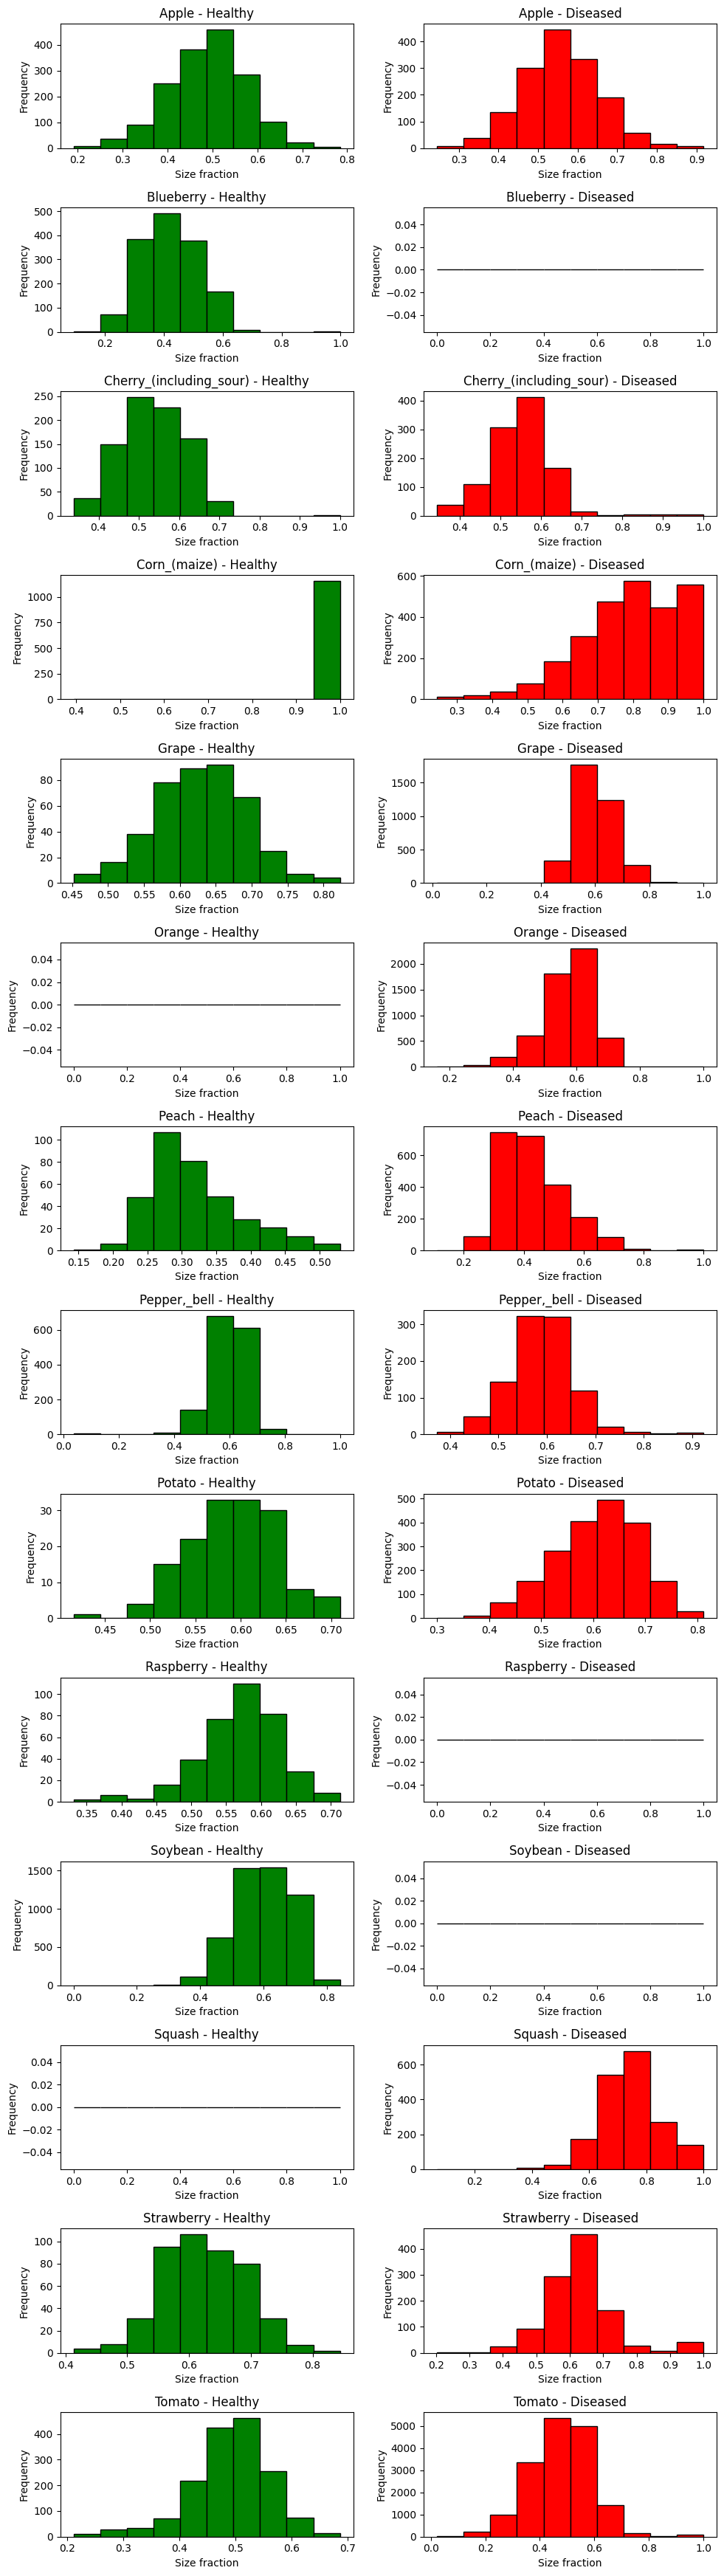

In [32]:
# Plot
fig, axes = plt.subplots(nrows=n_species, ncols=2, figsize=(10, 2.5*n_species))
if n_species == 1:
    axes = [axes]  # Make axes iterable if only one class

for i, (species, groups) in enumerate(species_groups.items()):
    # Healthy in green
    axes[i][0].hist(groups['healthy'], bins=10, edgecolor='black', color='green')
    axes[i][0].set_title(f"{species} - Healthy")
    axes[i][0].set_xlabel('Size fraction')
    axes[i][0].set_ylabel('Frequency')

    # Diseased in red
    axes[i][1].hist(groups['diseased'], bins=10, edgecolor='black', color='red')
    axes[i][1].set_title(f"{species} - Diseased")
    axes[i][1].set_xlabel('Size fraction')
    axes[i][1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

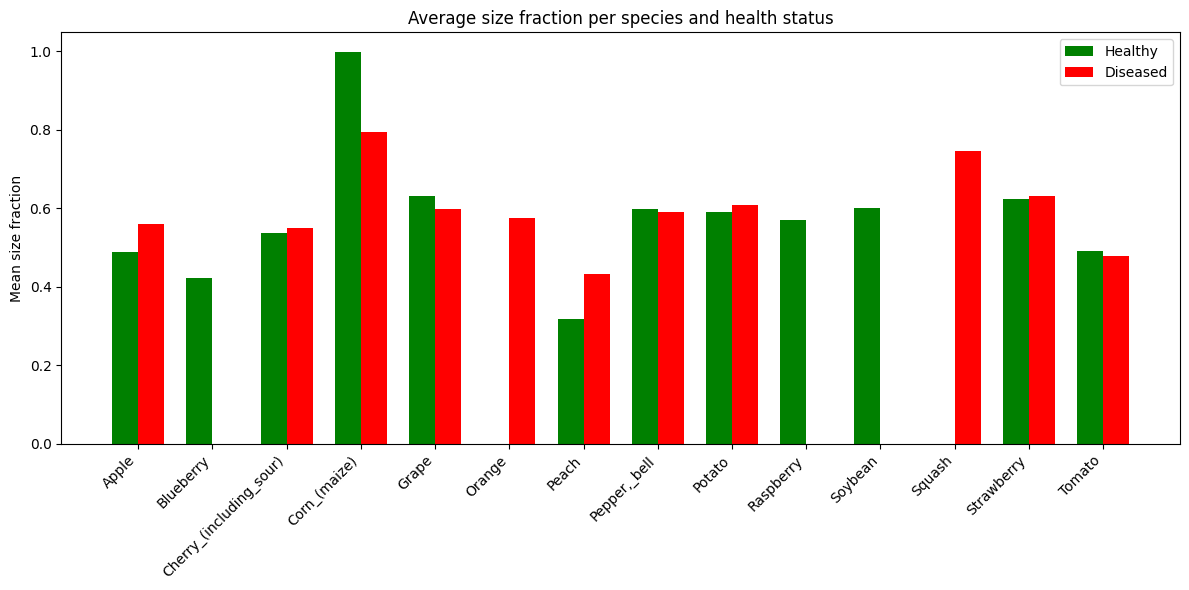

In [33]:
# Prepare lists to store species names and their mean values
species_list = []
healthy_means = []
non_healthy_means = []

# Calculate mean values for each species and group
for species, groups in species_groups.items():
    species_list.append(species)
    # Compute mean for healthy samples, default to 0 if empty
    healthy_means.append(np.mean(groups['healthy']) if groups['healthy'] else 0)
    # Compute mean for diseased samples, default to 0 if empty
    non_healthy_means.append(np.mean(groups['diseased']) if groups['diseased'] else 0)

# Set positions for the bars
x = np.arange(len(species_list))
width = 0.35  # Width of the bars

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for healthy and diseased means side by side
ax.bar(x - width/2, healthy_means, width, label='Healthy', color='green')
ax.bar(x + width/2, non_healthy_means, width, label='Diseased', color='red')

# Add labels, title, and xticks
ax.set_xticks(x)
ax.set_xticklabels(species_list, rotation=45, ha='right')
ax.set_ylabel('Mean size fraction')
ax.set_title('Average size fraction per species and health status')
ax.legend()

plt.tight_layout()
plt.show()

**OBSERVACIONES:**

- Se ve que mayorítariamente siguen una distribución normal los tamaños de hoja.

- No se observan diferencias de tamaño entre misma especie sana o enferma, salvo para el maiz.

- El tamaño promedio de hoja de las especies esta alrededor del 50%, 60% de la imagen, con excepción del maíz que ocupa un mayor tamaño.

### 2. MODEL #1: BASELINE

Como modelo baseline inicial, definimos una red neuronal simple sin data augmentation.

Generamos un objeto *config* para modificar parámetros durante la ejecución de experimentos.

In [34]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

#### 2.1 DATASET CONSTRUCTOR

Generamos un dataset con una mezcla aleatoria de las versiones ('color', 'grayscale', 'segmented'), donde para cada instancia, seleccionamos aleatoriamente de cada uno de los 3 datasets. Al mismo tiempo que mantenemos constante el tamaño del dataset (es decir, consumimos menos recursos computacionales), esperamos que el modelo generalize mejor con esta estrategia.

Posteriormente, convertimos el problema a uno de clasificación Multi-Output:

1. Clasificamos Multilabel para la especie de planta
2. Clasificación Binaria para el estado de la planta: 'Healthy' si está sana o 'Diseased' si presenta patología.

In [35]:
from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, datasets_list, seed=42, transform=None,
                    species_mapping=None, health_mapping=None):
        self.datasets = datasets_list
        self.length = len(self.datasets[0])  # Assume all datasets have same length
        self.seed = seed
        self.transform = transform
        self.species_mapping = species_mapping
        self.health_mapping = health_mapping

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        import random
        random.seed(self.seed + idx)                    # Se le suma idx para variar la semilla pero controlar la reproducibilidad
        chosen_dataset = random.choice(self.datasets)
        image, label_idx = chosen_dataset[idx]
        # Apply transformation if exists
        if self.transform:
            image = self.transform(image)

        # Map label to species and health status
        class_name_full = chosen_dataset.classes[label_idx]
        # Extract species from class name
        species_name = class_name_full.split("___")[0]
        # Map to species ID if mapping provided
        species_id = self.species_mapping[species_name] if self.species_mapping else species_name
        # Map to health status ID
        health_id = self.health_mapping[class_name_full]
        # Return image and label dictionary
        return image, {"species": species_id, "health": health_id}

# Generate mappings for species and health status:
species_names = set([name.split("___")[0] for name in class_names])
species_mapping = {name: idx for idx, name in enumerate(sorted(species_names))}

# For health status
health_mapping = {
    class_name: 0 if '__healthy' in class_name else 1
    for class_name in class_names
}

# Crear el nuevo dataset con etiquetas convertidas
rnd_seed = 42
dataset = TransformDataset([dataset_color, dataset_gray, dataset_seg],
                           seed=rnd_seed,
                           transform=ToTensor_transform,
                           species_mapping=species_mapping,
                           health_mapping=health_mapping)

ndata = len(dataset)

#### 2.2 TRAIN, VALIDATION & TEST SPLIT

Separamos el set construido en train, validation & test, en forma estratificada para respetar el desbalance de clases.

In [36]:
# Recover original labels for stratification
original_labels = [dataset_color.classes[label] for _, label in dataset_color]


In [37]:
from sklearn.model_selection import train_test_split

# Definimos fracciones para train/validation/test
val_size = 0.20
test_size = 0.20
train_size = 1 - (val_size + test_size)

# Generamos los sets
indices = list(range(ndata))
train_val_indices, test_indices = train_test_split(indices,
                                                   test_size = test_size,
                                                   stratify = original_labels,
                                                   random_state = rnd_seed)

train_indices, val_indices = train_test_split(train_val_indices,
                                            test_size=val_size / (train_size + val_size),
                                            stratify=[original_labels[i] for i in train_val_indices],
                                            random_state = rnd_seed)

# Calculamos la cantidad de elementos de cada set
ntrain = len(train_indices)
nval = len(val_indices)
ntest = len(test_indices)

train_data = torch.utils.data.Subset(dataset, train_indices)
val_data = torch.utils.data.Subset(dataset, val_indices)
test_data = torch.utils.data.Subset(dataset, test_indices)

print("Dimension del set de train:", ntrain)
print("Dimension del set de validation:", nval)
print("Dimension del set de test:", ntest)
print("")
print(f"Fracción de datos de train: {train_size:.2f}")
print(f"Fracción de datos de validation: {val_size:.2f}")
print(f"Fracción de datos de test: {test_size:.2f}")

Dimension del set de train: 32583
Dimension del set de validation: 10861
Dimension del set de test: 10861

Fracción de datos de train: 0.60
Fracción de datos de validation: 0.20
Fracción de datos de test: 0.20


Obtenemos la media y el desvío estándar del set de entrenamiento para la normalización de los pixeles de las imágenes.

In [38]:
def get_set_normalize_params(dataset, batch_size=64, seed=42):

    # get a random sample
    random.seed(seed)
    sample_indices = random.sample(range(len(dataset)), batch_size)

    all_pixels = []

    for idx in sample_indices:
        img, _ = dataset[idx]
        img = ToTensor_transform(img)
        all_pixels.append(img.reshape(-1))

    # Concatenar los píxeles del batch
    all_pixels_tensor = torch.cat(all_pixels)

    # Calcular media y std
    mean = all_pixels_tensor.mean().item()
    std = all_pixels_tensor.std().item()

    print(f'Media: {mean:.2g}')
    print(f'Desviación estándar: {std:.2g}')

    return mean, std

# Cargar el conjunto de entrenamiento sin aplicar transform (para calculo de mean y std)
# Consideramos diferentes batchs
mean_std = []
batch_list = [64, 128, 256, 512]
for bsize in batch_list:
    print(f'Batch size: {bsize}')
    mean_std.append(get_set_normalize_params(train_data, batch_size = bsize))
    print("")

# Recover las value
mean = mean_std[-1][0]
std = mean_std[-1][1]

Batch size: 64
Media: 0.38
Desviación estándar: 0.23

Batch size: 128
Media: 0.38
Desviación estándar: 0.24

Batch size: 256
Media: 0.37
Desviación estándar: 0.24

Batch size: 512
Media: 0.37
Desviación estándar: 0.25



Vemos que considerando un batch de 256 casos, ya se converge a un valor de media y desvío estándar.

Definimos una transformación para escalar a un mismo tamaño y normalizar todas las imágenes.

In [39]:
cfg.img_size = 224      # For resnet

# Definir transformaciones
# Transformación a todas las imagenes
normalized_transform = v2.Compose([
    v2.Resize((cfg.img_size, cfg.img_size)),                    # Resize images (just in case)
    v2.Normalize(mean=[mean], std=[std]),                       # Normalize channel
    ])

In [40]:
class TransformData(Dataset):
    def __init__(self, dataset, transform = None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data, label = self.dataset[idx]
        if self.transform:
            data = self.transform(data)
        return data, label

Lo aplicamos a los 3 sets:

In [41]:
train_data = TransformData(train_data, transform = normalized_transform)
val_data = TransformData(val_data, transform = normalized_transform)
test_data = TransformData(test_data, transform = normalized_transform)

#### 2.4 DATA LOADER

In [42]:
from torch.utils.data import DataLoader
cfg.batch_size = 32

# Cargamos los sets
train_loader = DataLoader(train_data, batch_size = cfg.batch_size, shuffle = True)
val_loader = DataLoader(val_data, batch_size = cfg.batch_size, shuffle = False)
test_loader = DataLoader(test_data, batch_size = cfg.batch_size, shuffle = False)

In [43]:
for images, labels in train_loader:
    print(images.shape)  # Imprime la forma de las imágenes
    print(labels)        # Imprime las etiquetas (números enteros codificados)
    break  # Salir después del primer lote

torch.Size([32, 3, 224, 224])
{'species': tensor([10, 10, 13, 13,  7,  3, 13,  7,  4,  4,  4,  9, 13, 13,  3,  0, 13, 10,
         7,  6, 13, 13, 13,  7,  3,  5,  1, 13, 10, 11, 10,  0]), 'health': tensor([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
        0, 1, 0, 1, 0, 1, 0, 0])}


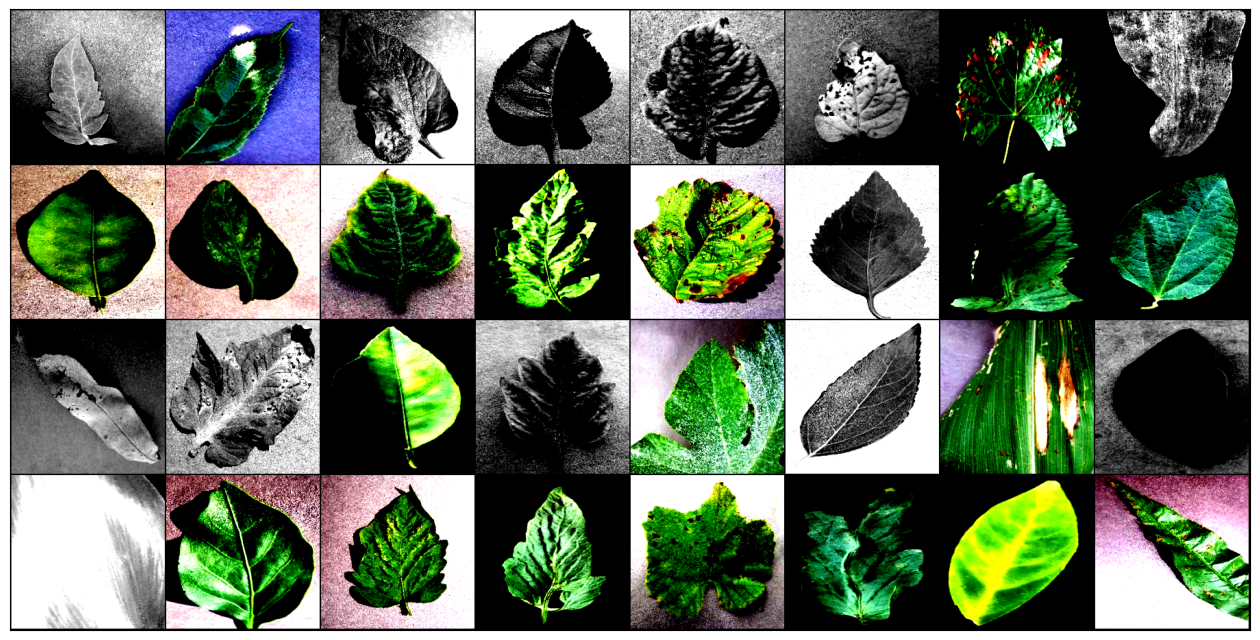

In [44]:
from torchvision.utils import make_grid

def show_batch(dl):
    """Plot images grid of single batch"""
    for images, labels in dl:
        fig,ax = plt.subplots(figsize = (16,12))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images,nrow=8).permute(1,2,0))
        break

show_batch(train_loader)

#### 2.5 MODEL DEFINITION

Definimos algunas funciones auxiliares de utilidad:

In [45]:
import torch.nn as nn
import torchinfo as torchinfo

# Bloque de convolución
def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2):
    return nn.Sequential(
                nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # conv
                nn.Tanh(),                                      # activation
                nn.MaxPool2d(pk)                                # pooling
                )

# Función auxiliar para calcular la dimensión de salida de la red convolucional
def calculate_output_dimensions(input_height,
                                input_width,
                                n_conv_layers,
                                kernel_size,
                                padding_type,
                                stride,
                                pooling_kernel_size):
    heights = []
    widths = []

    if padding_type == 'valid':
        padding = 0
    elif padding_type == 'same':
        padding = kernel_size // 2
    elif padding_type == 'full':
        padding = kernel_size - 1

    current_height = input_height
    current_width = input_width

    for _ in range(n_conv_layers):
        # Calcula la salida de la capa convolucional
        current_height = (current_height + 2 * padding - kernel_size) // stride + 1
        current_width = (current_width + 2 * padding - kernel_size) // stride + 1

        # Aplica el max pooling
        current_height = (current_height - pooling_kernel_size) // pooling_kernel_size + 1
        current_width = (current_width - pooling_kernel_size) // pooling_kernel_size + 1

        # Guarda la altura y el ancho después de cada capa
        heights.append(current_height)      # Guarda la altura
        widths.append(current_width)        # Guarda el ancho

    return heights, widths

Generamos la clase del modelo baseline:

In [46]:
class SimpleCNN(nn.Module):
  def __init__(self, n_channels=3, n_outputs=[n_species, 1], img_size = cfg.img_size):
    super().__init__()
    self.n_species = n_species

    # -----------------------------------------------------
    # CONVOLUTIONAL LAYERS
    # -----------------------------------------------------

    self.conv1 = conv_block(c_in = n_channels, c_out = 4, k=3, p='same', s=1, pk=2)
    self.conv1_out = None
    self.drop = torch.nn.Dropout2d(p=0.7, inplace=False)
    self.conv2 = conv_block(c_in = 4, c_out = 8, k=3, p='same', s=1, pk=2)
    self.conv2_out = None
    self.conv3 = conv_block(c_in = 8, c_out = 16, k=3, p='same', s=1, pk=2)

    conv_heights, conv_width = calculate_output_dimensions(img_size,
                                                          img_size,
                                                          n_conv_layers = 3,
                                                          kernel_size = 3,
                                                          padding_type = 'same',
                                                          stride = 1,
                                                          pooling_kernel_size = 2)

    # -----------------------------------------------------
    # FULLY CONNECTED OUTPUT LAYERS
    # -----------------------------------------------------

    conv_out_height = conv_heights[-1]  # Altura de salida de la última capa convolucional
    conv_out_width = conv_width[-1]     # Ancho de salida de la última capa convolucional

    num_ftrs = int(16*conv_out_height*conv_out_width)

    self.species_head = nn.Linear(num_ftrs, n_outputs[0])
    self.healthy_head = nn.Linear(num_ftrs, n_outputs[1])

  def forward(self, x):
    self.conv1_out = self.drop(self.conv1(x))
    self.conv2_out = self.drop(self.conv2(self.conv1_out))
    y = self.conv3(self.conv2_out)
    y = y.flatten(start_dim=1)

    species_logits = self.species_head(y)
    healthy_logits = self.healthy_head(y)

    return species_logits, healthy_logits


In [47]:
baseline = SimpleCNN()

# Print the model architecture
print(torchinfo.summary(baseline))

Layer (type:depth-idx)                   Param #
SimpleCNN                                --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       112
│    └─Tanh: 2-2                         --
│    └─MaxPool2d: 2-3                    --
├─Dropout2d: 1-2                         --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-4                       296
│    └─Tanh: 2-5                         --
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-4                        --
│    └─Conv2d: 2-7                       1,168
│    └─Tanh: 2-8                         --
│    └─MaxPool2d: 2-9                    --
├─Linear: 1-5                            175,630
├─Linear: 1-6                            12,545
Total params: 189,751
Trainable params: 189,751
Non-trainable params: 0


#### 2.6 DEFINITION OF TRAINING FUNCTIONS

Primeramente, configuramos el *device* acorde a los disponible:

In [48]:
cfg.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cfg.device

device(type='cuda', index=0)

In [49]:
# Define loss functions
criterion_species = nn.CrossEntropyLoss()  # For multi-class species classification
criterion_health = nn.BCEWithLogitsLoss()  # For binary healthy state prediction

# Optimizer general setup
cfg.learning_rate = 1e-4
cfg.lr_min = 1e-5

Definimos como métrica el f1-score ya que resulta una métrica adecuada para clases desbalanceadas.

In [50]:
from sklearn.metrics import f1_score

def calculate_metric(y, y_pred):
    # Compute the weighted F1-score
    metric = f1_score(y, y_pred, average='weighted')
    return metric

Definimos una función de training:

In [51]:
def train_one_epoch(dataloader, model, optimizer, scheduler, cfg):
    # Set the model to training mode
    model.train()

    # Lists to store true labels and predictions for metrics
    final_y_species = []
    final_y_health = []
    final_y_pred_species = []
    final_y_pred_health = []
    final_loss = []

    # Loop over the dataloader
    for step, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
        # Load inputs and labels to device
        X = batch[0].to(cfg.device)
        y_species = batch[1]['species'].to(cfg.device)
        y_health = batch[1]['health'].to(cfg.device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        with torch.set_grad_enabled(True):
            # Forward pass through the model
            species_logits, healthy_logits = model(X)

            # Compute individual losses
            loss_species = criterion_species(species_logits, y_species)
            loss_health = criterion_health(healthy_logits.squeeze(), y_health.float())

            # Sum the losses
            loss = loss_species + loss_health
            final_loss.append(loss.item())

            # Get predictions:
            pred_species = torch.argmax(species_logits, dim=1)  # shape [batch_size]
            pred_health = torch.sigmoid(healthy_logits).squeeze()  # shape [batch_size]
            pred_health_bin = (pred_health >= 0.5).type(torch.int)  # convert probabilities to classes 0/1

            # Detach and move to CPU for metrics
            y_species_np = y_species.detach().cpu().numpy().tolist()
            y_health_np = y_health.detach().cpu().numpy().astype(int).tolist()
            pred_species_np = pred_species.detach().cpu().numpy().tolist()
            pred_health_np = pred_health_bin.detach().cpu().numpy().tolist()

            # Store true labels and predictions for metrics
            final_y_species.extend(y_species_np)
            final_y_health.extend(y_health_np)
            final_y_pred_species.extend(pred_species_np)
            final_y_pred_health.extend(pred_health_np)

            # Backprop and optimize
            loss.backward()
            optimizer.step()

        # Step the scheduler
        scheduler.step()

    # Mean epoch loss
    loss_mean = np.mean(final_loss)

    # Calculate metrics for each output
    species_metric = calculate_metric(final_y_species, final_y_pred_species)
    health_metric = calculate_metric(final_y_health, final_y_pred_health)

    return {
        'species_metric': species_metric,
        'health_metric': health_metric,
        'loss': loss_mean
    }

Definimos una función de validación:

In [52]:
def validate_one_epoch(dataloader, model, cfg):
    # Set model to evaluation mode
    model.eval()

    final_y_species = []
    final_y_health = []
    final_y_pred_species = []
    final_y_pred_health = []
    final_loss = []

    # Iterate over data
    for step, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
        X = batch[0].to(cfg.device)
        y_species = batch[1]['species'].to(cfg.device)
        y_health = batch[1]['health'].to(cfg.device)

        with torch.no_grad():
            # Forward pass
            species_logits, healthy_logits = model(X)

            # Calculate losses
            loss_species = criterion_species(species_logits, y_species)
            loss_health = criterion_health(healthy_logits.squeeze(), y_health.float())

            # Total loss
            loss = loss_species + loss_health
            final_loss.append(loss.item())

            # Predictions
            pred_species = torch.argmax(species_logits, dim=1)
            pred_health = torch.sigmoid(healthy_logits).squeeze()

            # Convert to CPU numpy lists
            y_species_np = y_species.detach().cpu().numpy().tolist()
            y_health_np = y_health.detach().cpu().numpy().tolist()
            pred_species_np = pred_species.detach().cpu().numpy().tolist()
            pred_health_np = (pred_health >= 0.5).detach().cpu().numpy().tolist()

            # Store actual labels and predictions
            final_y_species.extend(y_species_np)
            final_y_health.extend(y_health_np)
            final_y_pred_species.extend(pred_species_np)
            final_y_pred_health.extend(pred_health_np)

    # Calculate mean loss
    loss_mean = np.mean(final_loss)

    # Compute selected metric for species
    species_metric = calculate_metric(final_y_species, final_y_pred_species)

    # Compute selected metric for health state
    health_metric = calculate_metric(final_y_health, final_y_pred_health)

    # Return metrics and loss
    return {
        'species_metric': species_metric,
        'health_metric': health_metric,
        'loss': loss_mean
    }

In [53]:
import random

def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    # In general seed PyTorch operations
    torch.manual_seed(seed)

    # If you are using CUDA on 1 GPU, seed it
    torch.cuda.manual_seed(seed)

    # If you are using CUDA on more than 1 GPU, seed them all
    torch.cuda.manual_seed_all(cfg.seed)

    # Certain operations in Cudnn are not deterministic, and this line will force them to behave!
    torch.backends.cudnn.deterministic = True

    # Disable the inbuilt cudnn auto-tuner that finds the best algorithm to use for your hardware.
    torch.backends.cudnn.benchmark = False

In [54]:
cfg.seed = 42

def fit(model, optimizer, scheduler, cfg, train_dataloader, valid_dataloader=None):
    # Lists to store metrics for training and validation
    train_metrics = []
    train_losses = []
    val_metrics = []
    val_losses = []

    for epoch in range(cfg.epochs):
        print(f"Epoch {epoch + 1}/{cfg.epochs}")

        # Set seed for reproducibility
        set_seed(cfg.seed + epoch)

        # Train for one epoch
        train_result = train_one_epoch(train_dataloader, model, optimizer, scheduler, cfg)
        print(f"Train Loss: {train_result['loss']:.4f}")
        print(f"Species Train F1: {train_result['species_metric']:.4f} Health Train F1: {train_result['health_metric']:.4f}")

        # Store training metrics
        train_metrics.append({
            'species_metric': train_result['species_metric'],
            'health_metric': train_result['health_metric'],
        })
        train_losses.append(train_result['loss'])

        if valid_dataloader:
            # Validation step
            val_result = validate_one_epoch(valid_dataloader, model, cfg)
            print(f"Val Loss: {val_result['loss']:.4f}")
            print(f"Species Val F1: {val_result['species_metric']:.4f} Health val F1: {val_result['health_metric']:.4f}")

            # Store validation metrics
            val_metrics.append({
                'species_metric': val_result['species_metric'],
                'health_metric': val_result['health_metric'],
            })
            val_losses.append(val_result['loss'])

    return train_metrics, train_losses, val_metrics, val_losses

In [55]:
def plot_history(train_f1, train_loss, val_f1, val_loss, title=None):
    # Extract species and health metrics for train_f1
    train_species = [epoch['species_metric'] for epoch in train_f1]
    train_health = [epoch['health_metric'] for epoch in train_f1]
    # Extract species and health metrics for val_f1
    val_species = [epoch['species_metric'] for epoch in val_f1]
    val_health = [epoch['health_metric'] for epoch in val_f1]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax[0].plot(range(len(train_loss)), train_loss, color='darkgrey', label='train')
    ax[0].plot(range(len(val_loss)), val_loss, color='cornflowerblue', label='validation')
    ax[0].set_title('Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].legend(loc='upper right')

    # Plot F1 scores
    ax[1].plot(range(len(train_species)), train_species, label='Species Train', color='blue')
    ax[1].plot(range(len(train_health)), train_health, label='Health Train', color='cyan')
    ax[1].plot(range(len(val_species)), val_species, label='Species Validation', color='red')
    ax[1].plot(range(len(val_health)), val_health, label='Health Validation', color='orange')
    ax[1].set_title('F1 scores')
    ax[1].set_xlabel('Epochs')
    ax[1].legend(loc='upper right')

    if title:
        plt.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

#### 2.7 ENTRENAMIENTO

Epoch 1/30


100%|██████████| 1019/1019 [01:09<00:00, 14.70it/s]


Train Loss: 2.6070
Species Train F1: 0.2927 Health Train F1: 0.6365


100%|██████████| 340/340 [00:21<00:00, 15.56it/s]


Val Loss: 2.3244
Species Val F1: 0.3816 Health val F1: 0.6822
Epoch 2/30


...

Val Loss: 1.6943
Species Val F1: 0.5605 Health val F1: 0.7604
Epoch 30/30


100%|██████████| 1019/1019 [01:08<00:00, 14.87it/s]


Train Loss: 1.7650
Species Train F1: 0.5904 Health Train F1: 0.7577


100%|██████████| 340/340 [00:22<00:00, 15.27it/s]


Val Loss: 1.6864
Species Val F1: 0.5662 Health val F1: 0.7585


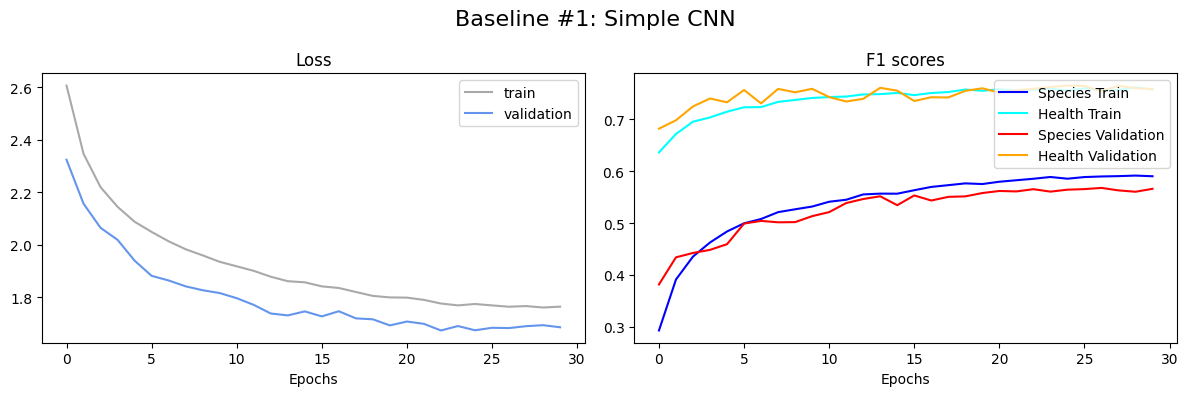

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
filename = 'PDC_baseline.pth'

if os.path.exists(filename):
    state_dict = torch.load('./' + filename, map_location=cfg.device)
    baseline.load_state_dict(state_dict)

else:
  cfg.epochs = 30

  optimizer = torch.optim.Adam(
    baseline.parameters(),
    lr = cfg.learning_rate,
    weight_decay = 0,
  )

  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max = np.ceil(len(train_loader.dataset) / cfg.batch_size) * cfg.epochs,
    eta_min = cfg.lr_min
  )

  baseline = baseline.to(cfg.device)
  train_f1, train_loss, val_f1, val_loss = fit(baseline,
                                              optimizer,
                                              scheduler,
                                              cfg,
                                              train_loader,
                                              val_loader)

  plot_history(train_f1, train_loss, val_f1, val_loss, title = 'Baseline #1: Simple CNN')

  # Save the trained model

  torch.save(baseline.state_dict(), filename)

  if IN_COLAB:  # Download the file
      from google.colab import files
      files.download(filename)

#### 2.8 PREDICCIÓN SOBRE EL TEST

In [57]:
# Test step
test_result = validate_one_epoch(test_loader, baseline, cfg)
print(f"Test Loss: {test_result['loss']:.4f}")
print(f"Species Test F1: {test_result['species_metric']:.4f} Health Test F1: {test_result['health_metric']:.4f}")

100%|██████████| 340/340 [00:21<00:00, 15.54it/s]

Test Loss: 1.6953
Species Test F1: 0.5611 Health Test F1: 0.7555


In [58]:
def predict(dataloader, model, cfg):
    model.eval()  # Modo evaluación

    final_species = []
    final_health = []

    # Iterar sobre los datos
    for step, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
        X = batch[0].to(cfg.device)

        with torch.no_grad():
            # Forward pass
            species_logits, healthy_logits = model(X)

            # Predicciones
            pred_species = torch.argmax(species_logits, dim=1)
            pred_health = torch.sigmoid(healthy_logits).squeeze()

            # Convertir predicciones a listas y acumular
            final_species.extend(pred_species.cpu().numpy())
            final_health.extend(pred_health.cpu().numpy())

    # Devolver como diccionario o lista
    return {
        'species': np.array(final_species),
        'health': (np.array(final_health) > 0.5).astype(int)
    }


# Usar la función predict con la instancia del modelo
y_pred_base = predict(test_loader, baseline, cfg)

# Recuperar las etiquetas verdaderas del set de test
species_labels = []
health_labels = []

for _, labels in test_loader:
    species_labels.extend(labels['species'].cpu().numpy())
    health_labels.extend(labels['health'].cpu().numpy())

y_test_species = np.array(species_labels)
y_test_health = np.array(health_labels)

100%|██████████| 340/340 [00:21<00:00, 15.61it/s]


In [59]:
experiments = [{
    'Modelo': 'Baseline #1 SimpleCNN',
    'epochs': cfg.epochs,
    'augmentation': None,
    'train_f1_species': train_f1[-1]['species_metric'],
    'train_f1_health': train_f1[-1]['health_metric'],
    'train_loss': train_loss[-1],
    'val_f1_species': val_f1[-1]['species_metric'],
    'val_f1_health': val_f1[-1]['health_metric'],
    'val_loss': val_loss[-1],
    'test_f1_species': test_result['species_metric'],
    'test_f1_health': test_result['health_metric'],
    'test_loss': test_result['loss'],
}]

### 3. MODEL #2: BASELINE WITH DATA AUGMENTATION

En este experimento, aplicamos el mismo modelo definido anteriormente, pero ejecutamos un Data Augmentation sobre el set de train previo al entrenamiento.

#### 3.1 DATA AUGMENTATION

Para hacer *data augmentation*, como primer aproximación, aprovechamos la funcionalidad *transforms*. En particular, aplicamos la técnica *RandAument*.

Este método necesita que se le especifiquen 2 parámetros:

- N:    Número transformaciones a aplicar secuencialmente.
- M:    Magnitud de todas las transformaciones. Valor entre [1, 10], donde 10 indica la máxima escala para una transformación dada.

Se pueden aplicar 14 tipos de transformaciones disponibles:

- identity
- rotate
- posterize
- sharpness
- translate-x
- autoContrast
- solarize
- contrast
- shear-x
- translate-y
- equalize
- color
- brightness
- shear-y

Más precisiones se pueden encontrar en Cubuk et. al. (2019),"RandAugment: Practical automated data augmentation with a reduced search space", 	arXiv:1909.13719, https://doi.org/10.48550/arXiv.1909.13719.

In [60]:
# Transformación para data augmentation
N = 2
M = 3
data_aug_transforms = v2.Compose([
                        v2.RandAugment(num_ops=N, magnitude=M),
    ])

Se la aplicamos al set de train:

In [61]:
aug_train_data = TransformData(train_data, transform=data_aug_transforms)

In [62]:
aug_train_loader = DataLoader(aug_train_data, batch_size = cfg.batch_size, shuffle = True)

#### 3.2 ENTRENAMIENTO

Epoch 1/30


100%|██████████| 1019/1019 [01:55<00:00,  8.85it/s]


Train Loss: 2.3997
Species Train F1: 0.4109 Health Train F1: 0.6964


100%|██████████| 340/340 [00:21<00:00, 15.70it/s]


Val Loss: 1.8911
Species Val F1: 0.5115 Health val F1: 0.7359
Epoch 2/30


...

Val Loss: 1.6099
Species Val F1: 0.5974 Health val F1: 0.7331
Epoch 30/30


100%|██████████| 1019/1019 [01:56<00:00,  8.78it/s]


Train Loss: 2.0626
Species Train F1: 0.5017 Health Train F1: 0.7105


100%|██████████| 340/340 [00:22<00:00, 15.25it/s]


Val Loss: 1.5648
Species Val F1: 0.6170 Health val F1: 0.7241


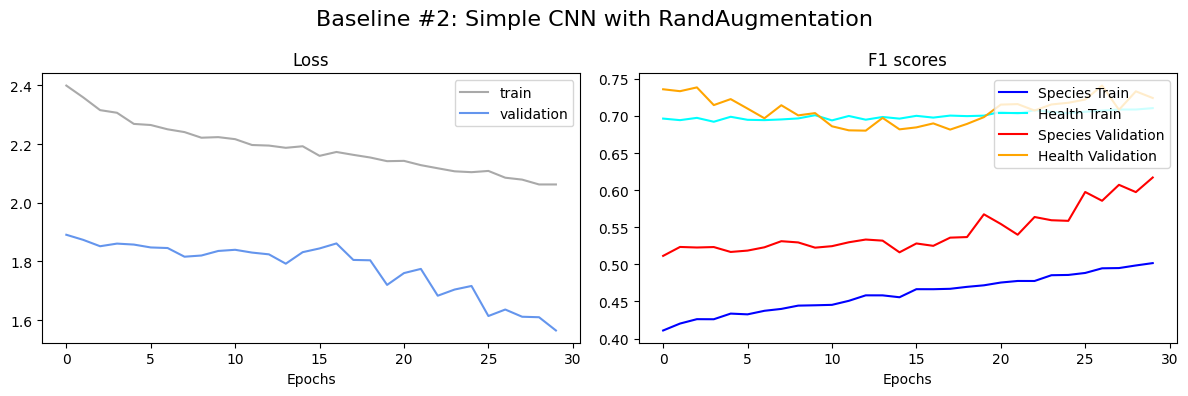

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
filename = 'PDC_baseline_wRA.pth'

if os.path.exists(filename):
    state_dict = torch.load('./' + filename, map_location=cfg.device)
    baseline.load_state_dict(state_dict)
else:
    train_f1, train_loss, val_f1, val_loss = fit(baseline,
                                                optimizer,
                                                scheduler,
                                                cfg,
                                                aug_train_loader,
                                                val_loader)

    plot_history(train_f1, train_loss, val_f1, val_loss, title = 'Baseline #2: Simple CNN with RandAugmentation')

    # Save the trained model
    torch.save(baseline.state_dict(), filename)

    if IN_COLAB:  # Download the file
        from google.colab import files
        files.download(filename)

In [64]:
# Test step
test_result = validate_one_epoch(test_loader, baseline, cfg)
print(f"Test Loss: {test_result['loss']:.4f}")
print(f"Species Test F1: {test_result['species_metric']:.4f} Health Test F1: {test_result['health_metric']:.4f}")

100%|██████████| 340/340 [00:21<00:00, 15.62it/s]

Test Loss: 1.5698
Species Test F1: 0.6164 Health Test F1: 0.7228


In [65]:
# Usar la función predict con la instancia del modelo
y_pred_base = predict(test_loader, baseline, cfg)

100%|██████████| 340/340 [00:21<00:00, 15.60it/s]


In [66]:
experiments.append({
    'Modelo': 'Baseline #2 SimpleCNN w/DA',
    'epochs': cfg.epochs,
    'augmentation': 'RandAugmentation',
    'train_f1_species': train_f1[-1]['species_metric'],
    'train_f1_health': train_f1[-1]['health_metric'],
    'train_loss': train_loss[-1],
    'val_f1_species': val_f1[-1]['species_metric'],
    'val_f1_health': val_f1[-1]['health_metric'],
    'val_loss': val_loss[-1],
    'test_f1_species': test_result['species_metric'],
    'test_f1_health': test_result['health_metric'],
    'test_loss': test_result['loss'],
})

### 4. MODEL #3: PRE-TRAINED RESNET18

En este modelo, se levanta la red RESNET18 y se ajustan los pesos de las cabezas de clasificación (Feature extraction approach).

In [67]:
import torchvision.models as models

# Configuration setup
cfg.backbone = 'resnet18'
cfg.weights = "IMAGENET1K_V1"       # Pre-trained weights (Only available option por RESNET18)
cfg.n_classes_species = n_species   # Number of species categories
cfg.healthy_state = 1               # Binary output for healthy state

# Create the base model using torchvision
model = getattr(models, cfg.backbone)(weights = cfg.weights)

# # Freeze backbone model
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer for species classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, cfg.n_classes_species)

# Add an additional head for healthy state binary prediction
model.healthy_head = nn.Linear(num_ftrs, cfg.healthy_state)

# Unfreeze classification heads for training
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.healthy_head.parameters():
    param.requires_grad = True

# Print the model architecture
print(torchinfo.summary(model))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 229MB/s]

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            (9,408)
├─BatchNorm2d: 1-2                       (128)
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  (36,864)
│    │    └─BatchNorm2d: 3-2             (128)
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  (36,864)
│    │    └─BatchNorm2d: 3-5             (128)
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  (36,864)
│    │    └─BatchNorm2d: 3-7             (128)
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  (36,864)
│    │    └─BatchNorm2d: 3-10            (128)
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11   

In [68]:
# Print freeze/trainable parameters
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

In [69]:
# Define the complete multi-output model
class MultiOutputModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

# Define the multi-output model
class MultiOutputModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        # Extract features part of the model (excluding original fc)
        self.features = nn.Sequential(
            self.base_model.conv1,
            self.base_model.bn1,
            self.base_model.relu,
            self.base_model.maxpool,
            self.base_model.layer1,
            self.base_model.layer2,
            self.base_model.layer3,
            self.base_model.layer4,
            self.base_model.avgpool
        )
        self.flatten = nn.Flatten()
        self.species_head = self.base_model.fc
        self.health_head = self.base_model.healthy_head

    def forward(self, x):
        features = self.features(x)
        features = self.flatten(features)
        species_logits = self.species_head(features)
        healthy_logits = self.health_head(features)
        return species_logits, healthy_logits

# Instantiate the multi-output model
rn18_multimodel = MultiOutputModel(model)
rn18_multimodel = rn18_multimodel.to(cfg.device)


Chequeamos el output size pasando un batch simple con 3 canales de valores random para el tamaño de imagen seteado.

In [70]:
X = torch.randn(cfg.batch_size, 3, cfg.img_size, cfg.img_size)
X = X.to(cfg.device)
outputs = rn18_multimodel(X)
species_preds, healthy_preds = outputs

print("Species logits shape:", species_preds.shape)
print("Healthy logits shape:", healthy_preds.shape)

Species logits shape: torch.Size([32, 14])
Healthy logits shape: torch.Size([32, 1])


Generamos una función para samplear los sets para hacer pruebas.

In [71]:
def get_sample_loaders(train_dataset, val_dataset, train_sample_size, val_sample_size, batch_size):
    # Randomly sample indices from the training dataset
    train_indices = torch.randperm(len(train_dataset))[:train_sample_size].tolist()
    # Randomly sample indices from the validation dataset
    val_indices = torch.randperm(len(val_dataset))[:val_sample_size].tolist()

    # Create Samplers for train and validation
    train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
    val_sampler = torch.utils.data.SubsetRandomSampler(val_indices)

    # Create DataLoader with the sampled data
    train_loader_sample = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    val_loader_sample = DataLoader(val_dataset, batch_size=batch_size, sampler=val_sampler)

    return train_loader_sample, val_loader_sample

# TODO: tomar el subsampleo en forma estratificada.

In [72]:
# Sample sizes for loaders (adjust this as needed)
cfg.sample_fraction = 0.05
train_sample_size = int(ntrain * cfg.sample_fraction)   # Number of samples for training
val_sample_size = int(nval * cfg.sample_fraction)       # Number of samples for validation

# Get sample loaders for the objective function
train_loader_sample, val_loader_sample = get_sample_loaders(train_loader.dataset, val_loader.dataset, train_sample_size, val_sample_size, cfg.batch_size)

Epoch 1/5


100%|██████████| 1019/1019 [01:09<00:00, 14.64it/s]


Train Loss: 1.8028
Species Train F1: 0.5804 Health Train F1: 0.7412


100%|██████████| 340/340 [00:22<00:00, 15.11it/s]


Val Loss: 1.1043
Species Val F1: 0.7974 Health val F1: 0.8628
Epoch 2/5


...

Val Loss: 0.5932
Species Val F1: 0.9295 Health val F1: 0.9185
Epoch 5/5


100%|██████████| 1019/1019 [01:09<00:00, 14.67it/s]


Train Loss: 0.6288
Species Train F1: 0.9155 Health Train F1: 0.9088


100%|██████████| 340/340 [00:22<00:00, 15.26it/s]


Val Loss: 0.5686
Species Val F1: 0.9334 Health val F1: 0.9164


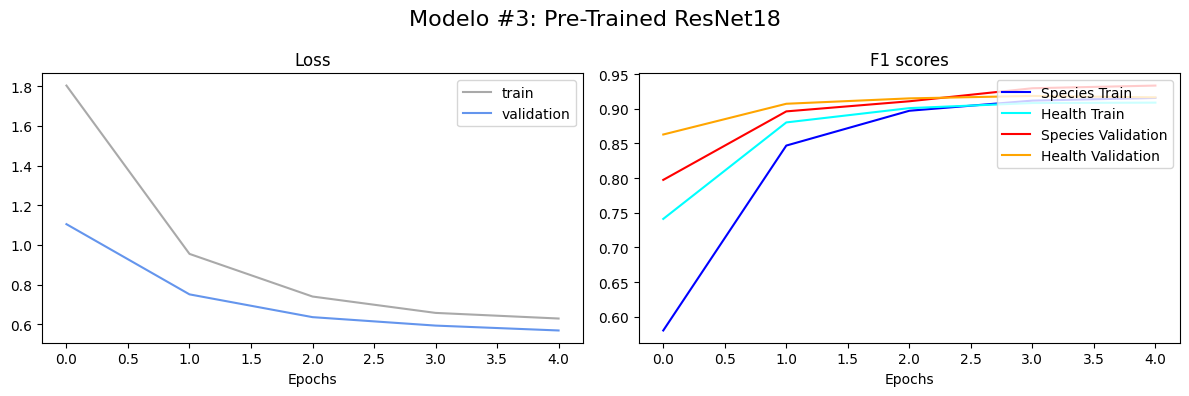

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
filename = 'PDC_ptRN18.pth'

if os.path.exists(filename):
    state_dict = torch.load('./' + filename, map_location=cfg.device)
    rn18_multimodel.load_state_dict(state_dict)
else:
    cfg.epochs = 5

    optimizer = torch.optim.Adam(
      rn18_multimodel.parameters(),
      lr = cfg.learning_rate,
      weight_decay = 0,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      optimizer,
      T_max = np.ceil(len(train_loader.dataset) / cfg.batch_size) * cfg.epochs,
      eta_min = cfg.lr_min
    )
    train_f1, train_loss, val_f1, val_loss = fit(rn18_multimodel,
                                                            optimizer,
                                                            scheduler,
                                                            cfg,
                                                            train_loader,
                                                            val_loader)

    plot_history(train_f1, train_loss, val_f1, val_loss, title = 'Modelo #3: Pre-Trained ResNet18')

    # Save the trained model
    torch.save(rn18_multimodel.state_dict(), filename)

    if IN_COLAB:  # Download the file
        from google.colab import files
        files.download(filename)

#### 4.1 Predicciones sobre el Test set

In [74]:
# Test step
test_result = validate_one_epoch(test_loader, rn18_multimodel, cfg)
print(f"Test Loss: {test_result['loss']:.4f}")
print(f"Species Test F1: {test_result['species_metric']:.4f} Health Test F1: {test_result['health_metric']:.4f}")

100%|██████████| 340/340 [00:22<00:00, 15.09it/s]

Test Loss: 0.5641
Species Test F1: 0.9314 Health Test F1: 0.9172


In [75]:
# Usar la función predict con la instancia del modelo
y_pred_rn18pt = predict(test_loader, rn18_multimodel, cfg)

100%|██████████| 340/340 [00:22<00:00, 15.40it/s]


In [76]:
experiments.append(
    {
    'Modelo': 'Model #3: PRE-TRAINED RESNET18',
    'epochs': cfg.epochs,
    'augmentation': None,
    'train_f1_species': train_f1[-1]['species_metric'],
    'train_f1_health': train_f1[-1]['health_metric'],
    'train_loss': train_loss[-1],
    'val_f1_species': val_f1[-1]['species_metric'],
    'val_f1_health': val_f1[-1]['health_metric'],
    'val_loss': val_loss[-1],
    'test_f1_species': test_result['species_metric'],
    'test_f1_health': test_result['health_metric'],
    'test_loss': test_result['loss'],
        }
    )

### 5. MODEL #4: RESNET18

En este caso, entrenammos completamente la arquitectura ResNet18 con nuestro dataset.

In [77]:
# Unfreeze backbone model
for param in model.parameters():
    param.requires_grad = True

# Print the model architecture
print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  36,864
│    │    └─BatchNorm2d: 3-7             128
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  36,864
│    │    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11                 73,728

Epoch 1/5


100%|██████████| 1019/1019 [01:14<00:00, 13.60it/s]


Train Loss: 0.1170
Species Train F1: 0.9841 Health Train F1: 0.9789


100%|██████████| 340/340 [00:22<00:00, 15.36it/s]


Val Loss: 0.0375
Species Val F1: 0.9939 Health val F1: 0.9938
Epoch 2/5


...

Val Loss: 0.0139
Species Val F1: 0.9987 Health val F1: 0.9968
Epoch 5/5


100%|██████████| 1019/1019 [01:15<00:00, 13.56it/s]


Train Loss: 0.0034
Species Train F1: 0.9999 Health Train F1: 0.9996


100%|██████████| 340/340 [00:22<00:00, 15.39it/s]


Val Loss: 0.0121
Species Val F1: 0.9990 Health val F1: 0.9972


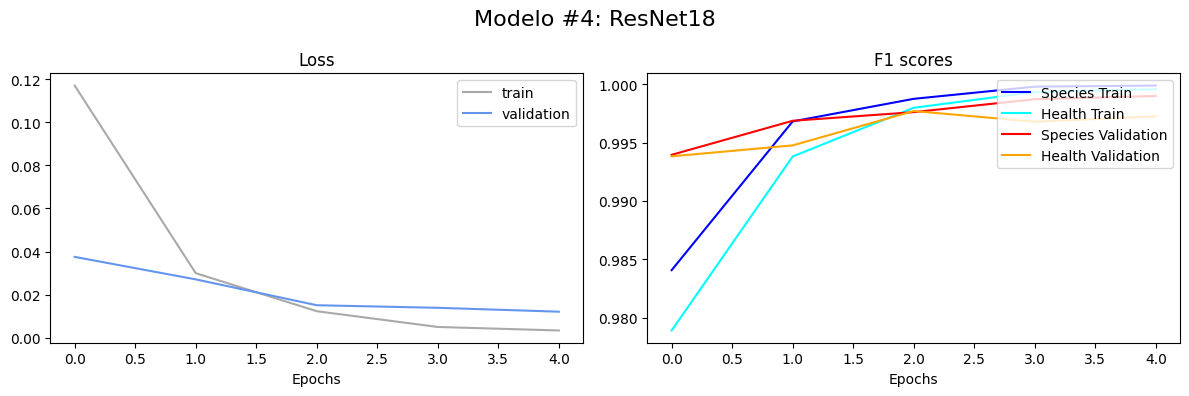

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
filename = 'PDC_RN18_ ft.pth'

if os.path.exists(filename):
    state_dict = torch.load('./' + filename, map_location=cfg.device)
    rn18_multimodel.load_state_dict(state_dict)
else:
    cfg.epochs = 5

    optimizer = torch.optim.Adam(
            rn18_multimodel.parameters(),
            lr = cfg.learning_rate,
            weight_decay = 0,
            )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      optimizer,
      T_max = np.ceil(len(train_loader.dataset) / cfg.batch_size) * cfg.epochs,
      eta_min = cfg.lr_min
    )

    train_f1, train_loss, val_f1, val_loss = fit(rn18_multimodel,
                                                            optimizer,
                                                            scheduler,
                                                            cfg,
                                                            train_loader,
                                                            val_loader)

    plot_history(train_f1, train_loss, val_f1, val_loss, title = 'Modelo #4: ResNet18')

    # Save the trained model
    torch.save(rn18_multimodel.state_dict(), filename)

    if IN_COLAB:  # Download the file
        from google.colab import files
        files.download(filename)

#### 5.1 Predicciones sobre el Test set

In [79]:
# Test step
test_result = validate_one_epoch(test_loader, rn18_multimodel, cfg)
print(f"Test Loss: {test_result['loss']:.4f}")
print(f"Species Test F1: {test_result['species_metric']:.4f} Health Test F1: {test_result['health_metric']:.4f}")

100%|██████████| 340/340 [00:22<00:00, 15.21it/s]

Test Loss: 0.0154
Species Test F1: 0.9980 Health Test F1: 0.9977


In [80]:
# Usar la función predict con la instancia del modelo
y_pred_rn18 = predict(test_loader, rn18_multimodel, cfg)

100%|██████████| 340/340 [00:22<00:00, 15.28it/s]


In [81]:
experiments.append(
    {
    'Modelo': 'Model #4: RESNET18',
    'epochs': cfg.epochs,
    'augmentation': None,
    'train_f1_species': train_f1[-1]['species_metric'],
    'train_f1_health': train_f1[-1]['health_metric'],
    'train_loss': train_loss[-1],
    'val_f1_species': val_f1[-1]['species_metric'],
    'val_f1_health': val_f1[-1]['health_metric'],
    'val_loss': val_loss[-1],
    'test_f1_species': test_result['species_metric'],
    'test_f1_health': test_result['health_metric'],
    'test_loss': test_result['loss'],
        }
    )

#### 5.2 Confusión

In [82]:
from sklearn.metrics import confusion_matrix

# Matriz de confusión para especie
cm_species = confusion_matrix(y_test_species, y_pred_rn18['species'], labels=range(n_species))
cm_species_normalized = cm_species.astype('float') / cm_species.sum(axis=1)[:, np.newaxis]

# Matriz de confusión para health status
cm_health = confusion_matrix(y_test_health,y_pred_rn18['health'], labels=[0, 1])
cm_health_normalized = cm_health.astype('float') / cm_health.sum(axis=1)[:, np.newaxis]


In [102]:
species_list = sorted(list(species_names))

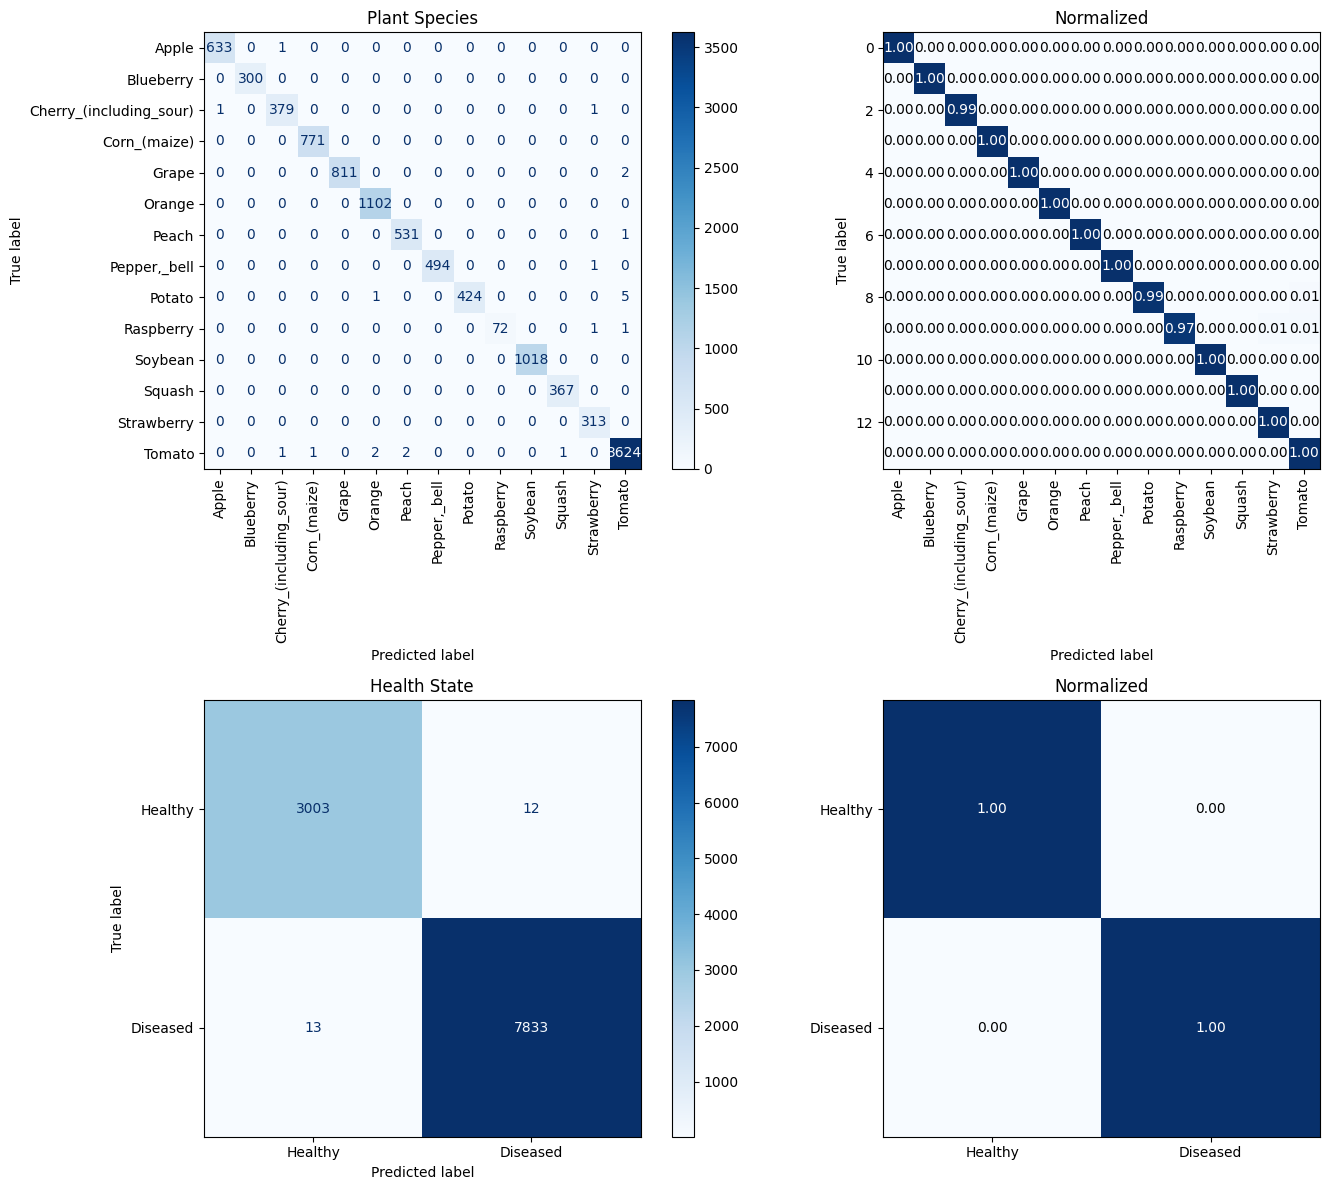

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay

# Crear la figura 2x2
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# ======================
# First row: "Plant species"
# ======================

disp_spec = ConfusionMatrixDisplay(confusion_matrix=cm_species, display_labels=sorted(list(species_names)))
disp_spec.plot(ax=axs[0, 0], cmap='Blues')
axs[0, 0].set_title("Plant Species")
axs[0, 0].grid(False)
axs[0, 0].set_xticklabels(sorted(list(species_names)), rotation=90)

# Normalized
im_spec_norm = axs[0, 1].imshow(cm_species_normalized, cmap='Blues')
for i in range(cm_species_normalized.shape[0]):
    for j in range(cm_species_normalized.shape[1]):
        val = cm_species_normalized[i, j]
        axs[0, 1].text(j, i, f"{val:.2f}", ha='center', va='center',
                       color='white' if val > 0.5 else 'black')
axs[0, 1].set_xticks(np.arange(len(species_names)))
axs[0, 1].set_xticklabels(sorted(list(species_names)), rotation=90)
axs[0, 1].set_title("Normalized")
axs[0, 1].set_xlabel('Predicted label')
axs[0, 1].set_ylabel('True label')

# ======================
# Second row: "Health state"
# ======================

# Sin normalizar
disp_health = ConfusionMatrixDisplay(confusion_matrix=cm_health, display_labels=['Healthy', 'Diseased'])
disp_health.plot(ax=axs[1, 0], cmap='Blues')
axs[1, 0].set_title("Health State")
axs[1, 0].grid(False)
axs[1, 0].set_xticks(np.arange(2))
axs[1, 0].set_xticklabels(['Healthy', 'Diseased'])
axs[1, 0].set_yticks(np.arange(2))
axs[1, 0].set_yticklabels(['Healthy', 'Diseased'])

# Normalizada
im_health_norm = axs[1, 1].imshow(cm_health_normalized, cmap='Blues')
for i in range(cm_health_normalized.shape[0]):
    for j in range(cm_health_normalized.shape[1]):
        val = cm_health_normalized[i, j]
        axs[1, 1].text(j, i, f"{val:.2f}", ha='center', va='center',
                       color='white' if val > 0.5 else 'black')
axs[1, 1].set_xticks(np.arange(2))
axs[1, 1].set_xticklabels(['Healthy', 'Diseased'])
axs[1, 1].set_yticks(np.arange(2))
axs[1, 1].set_yticklabels(['Healthy', 'Diseased'])
axs[1, 1].set_title("Normalized")

plt.tight_layout()
plt.show()



#### 4.3 Clasification report

In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test_species, y_pred_rn18['species'], target_names=sorted(list(species_names))))

                         precision    recall  f1-score   support

                  Apple       1.00      1.00      1.00       634
              Blueberry       1.00      1.00      1.00       300
Cherry_(including_sour)       0.99      0.99      0.99       381
           Corn_(maize)       1.00      1.00      1.00       771
                  Grape       1.00      1.00      1.00       813
                 Orange       1.00      1.00      1.00      1102
                  Peach       1.00      1.00      1.00       532
           Pepper,_bell       1.00      1.00      1.00       495
                 Potato       1.00      0.99      0.99       430
              Raspberry       1.00      0.97      0.99        74
                Soybean       1.00      1.00      1.00      1018
                 Squash       1.00      1.00      1.00       367
             Strawberry       0.99      1.00      1.00       313
                 Tomato       1.00      1.00      1.00      3631

               accuracy

In [85]:

print(classification_report(y_test_health, y_pred_rn18['health'], target_names=['Healthy', 'Diseased']))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      3015
    Diseased       1.00      1.00      1.00      7846

    accuracy                           1.00     10861
   macro avg       1.00      1.00      1.00     10861
weighted avg       1.00      1.00      1.00     10861



### 6. COMPARACIÓN DE MODELOS Y CONCLUSIONES

In [86]:
df_experiments = pd.DataFrame(experiments)
df_experiments

,Modelo,epochs,augmentation,train_f1_species,train_f1_health,train_loss,val_f1_species,val_f1_health,val_loss,test_f1_species,test_f1_health,test_loss
0,Baseline #1 SimpleCNN,30,None,0.590410,0.757719,1.764966,0.566165,0.758453,1.686380,0.561117,0.755518,1.695341
1,Baseline #2 SimpleCNN w/DA,30,RandAugmentation,0.501710,0.710493,2.062555,0.617044,0.724147,1.564758,0.616378,0.722842,1.569785
2,Model #3: PRE-TRAINED RESNET18,5,None,0.915550,0.908792,0.628820,0.933369,0.916365,0.568563,0.931387,0.917163,0.564067
3,Model #4: RESNET18,5,None,0.999877,0.999570,0.003371,0.998987,0.997238,0.012096,0.997972,0.997698,0.015424


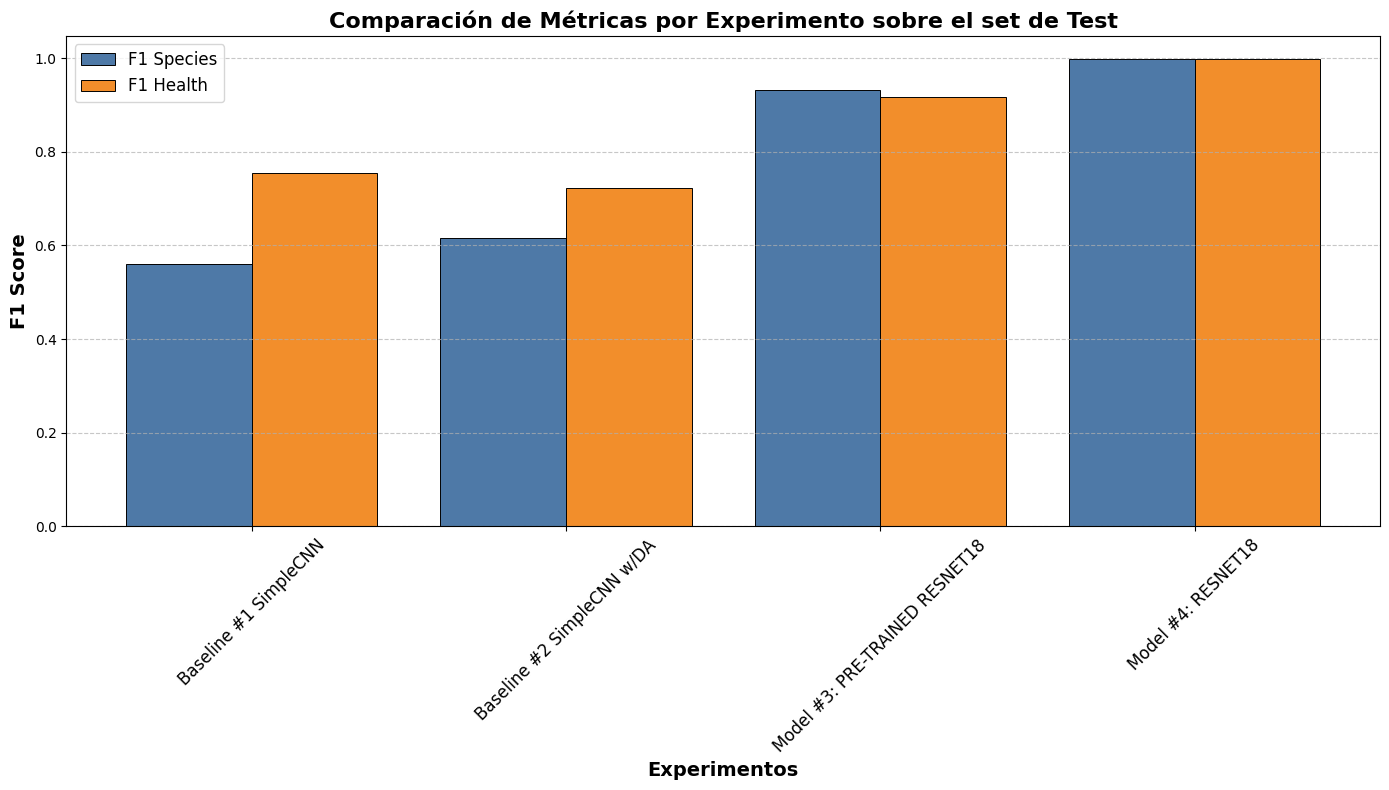

In [87]:
# Número de experimentos
x = np.arange(len(df_experiments))
width = 0.4  # Ancho de las barras

# Configuración de colores y estilos
colors = ['#4E79A7', '#F28E2B']
labels = ['F1 Species', 'F1 Health']

# Crear la figura con tamaño mayor para mejor visualización
plt.figure(figsize=(14, 8))

# Barras agrupadas con estética
plt.bar(x - width/2, df_experiments['test_f1_species'], width,
        label=labels[0], color=colors[0], edgecolor='black', linewidth=0.7)
plt.bar(x + width/2, df_experiments['test_f1_health'], width,
        label=labels[1], color=colors[1], edgecolor='black', linewidth=0.7)

# Mejor organización de etiquetas
plt.xlabel('Experimentos', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontsize=14, fontweight='bold')
plt.title('Comparación de Métricas por Experimento sobre el set de Test', fontsize=16, fontweight='bold')

# Configurar las etiquetas del eje x con rotación y posición
plt.xticks(x, df_experiments['Modelo'], rotation=45, fontsize=12)

# Añadir cuadrícula suave y sutil
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir leyenda con marco
plt.legend(frameon=True, fontsize=12)

# Mejor ajuste y diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()


- El modelo baseline con y sin Data Augmentation presenta una perfomance similar, notandose una leve mejora en el modelo con Data Augmentation para la clasificación de especie de planta.

- Posiblemente se requieran más epochs para entrenar los modelos baseline a su límite de performance.

- Ambos modelos ResNet18 (pre-trained & fully-trained) presentaron una métrica f1-score muy superior a las redes simples, con menor epochs de entrenamiento y menor tiempo usando GPUs A100 de COLAB.

- El mejor modelo en términos de la métrica aplicada resulto ResNet18 con entrenamiento completo.